In [22]:
import torch
import os

def print_stat_summary(save_dir, keywords=['q_proj', 'v_proj']):
    files = {
        "epoch0 weights": "epoch0_layer_weights.pt",
        # "epoch1 weights": "epoch1_layer_weights.pt",
        # "epoch0 gradients": "epoch0_layer_gradients.pt"
    }

    for label, file_name in files.items():
        print(f"\n🔍 {label.upper()}")
        file_path = os.path.join(save_dir, file_name)
        data = torch.load(file_path)

        for name, tensor in data.items():
            if not any(k in name for k in keywords):
                continue

            mean_val = tensor.float().mean().item()
            std_val = tensor.float().std().item()
            print(f"{name:<80} | mean: {mean_val:.4e} | std: {std_val:.4e} | shape: {tuple(tensor.shape)}")
print_stat_summary("parameters/Copa/gradient_masking_0.999-1e-5-8274")



🔍 EPOCH0 WEIGHTS
model.decoder.layers.0.self_attn.v_proj.tunable_weight                           | mean: -1.5511e-05 | std: 1.2773e-02 | shape: (768, 768)
model.decoder.layers.0.self_attn.v_proj.base_Linear.weight                       | mean: -1.5511e-05 | std: 1.2773e-02 | shape: (768, 768)
model.decoder.layers.0.self_attn.v_proj.base_Linear.bias                         | mean: -3.9819e-04 | std: 1.3329e-02 | shape: (768,)
model.decoder.layers.0.self_attn.q_proj.tunable_weight                           | mean: -3.1481e-05 | std: 7.8675e-02 | shape: (768, 768)
model.decoder.layers.0.self_attn.q_proj.base_Linear.weight                       | mean: -3.1481e-05 | std: 7.8675e-02 | shape: (768, 768)
model.decoder.layers.0.self_attn.q_proj.base_Linear.bias                         | mean: -6.1576e-04 | std: 2.3489e-01 | shape: (768,)
model.decoder.layers.1.self_attn.v_proj.tunable_weight                           | mean: 1.3618e-05 | std: 1.5709e-02 | shape: (768, 768)
model.decoder.laye

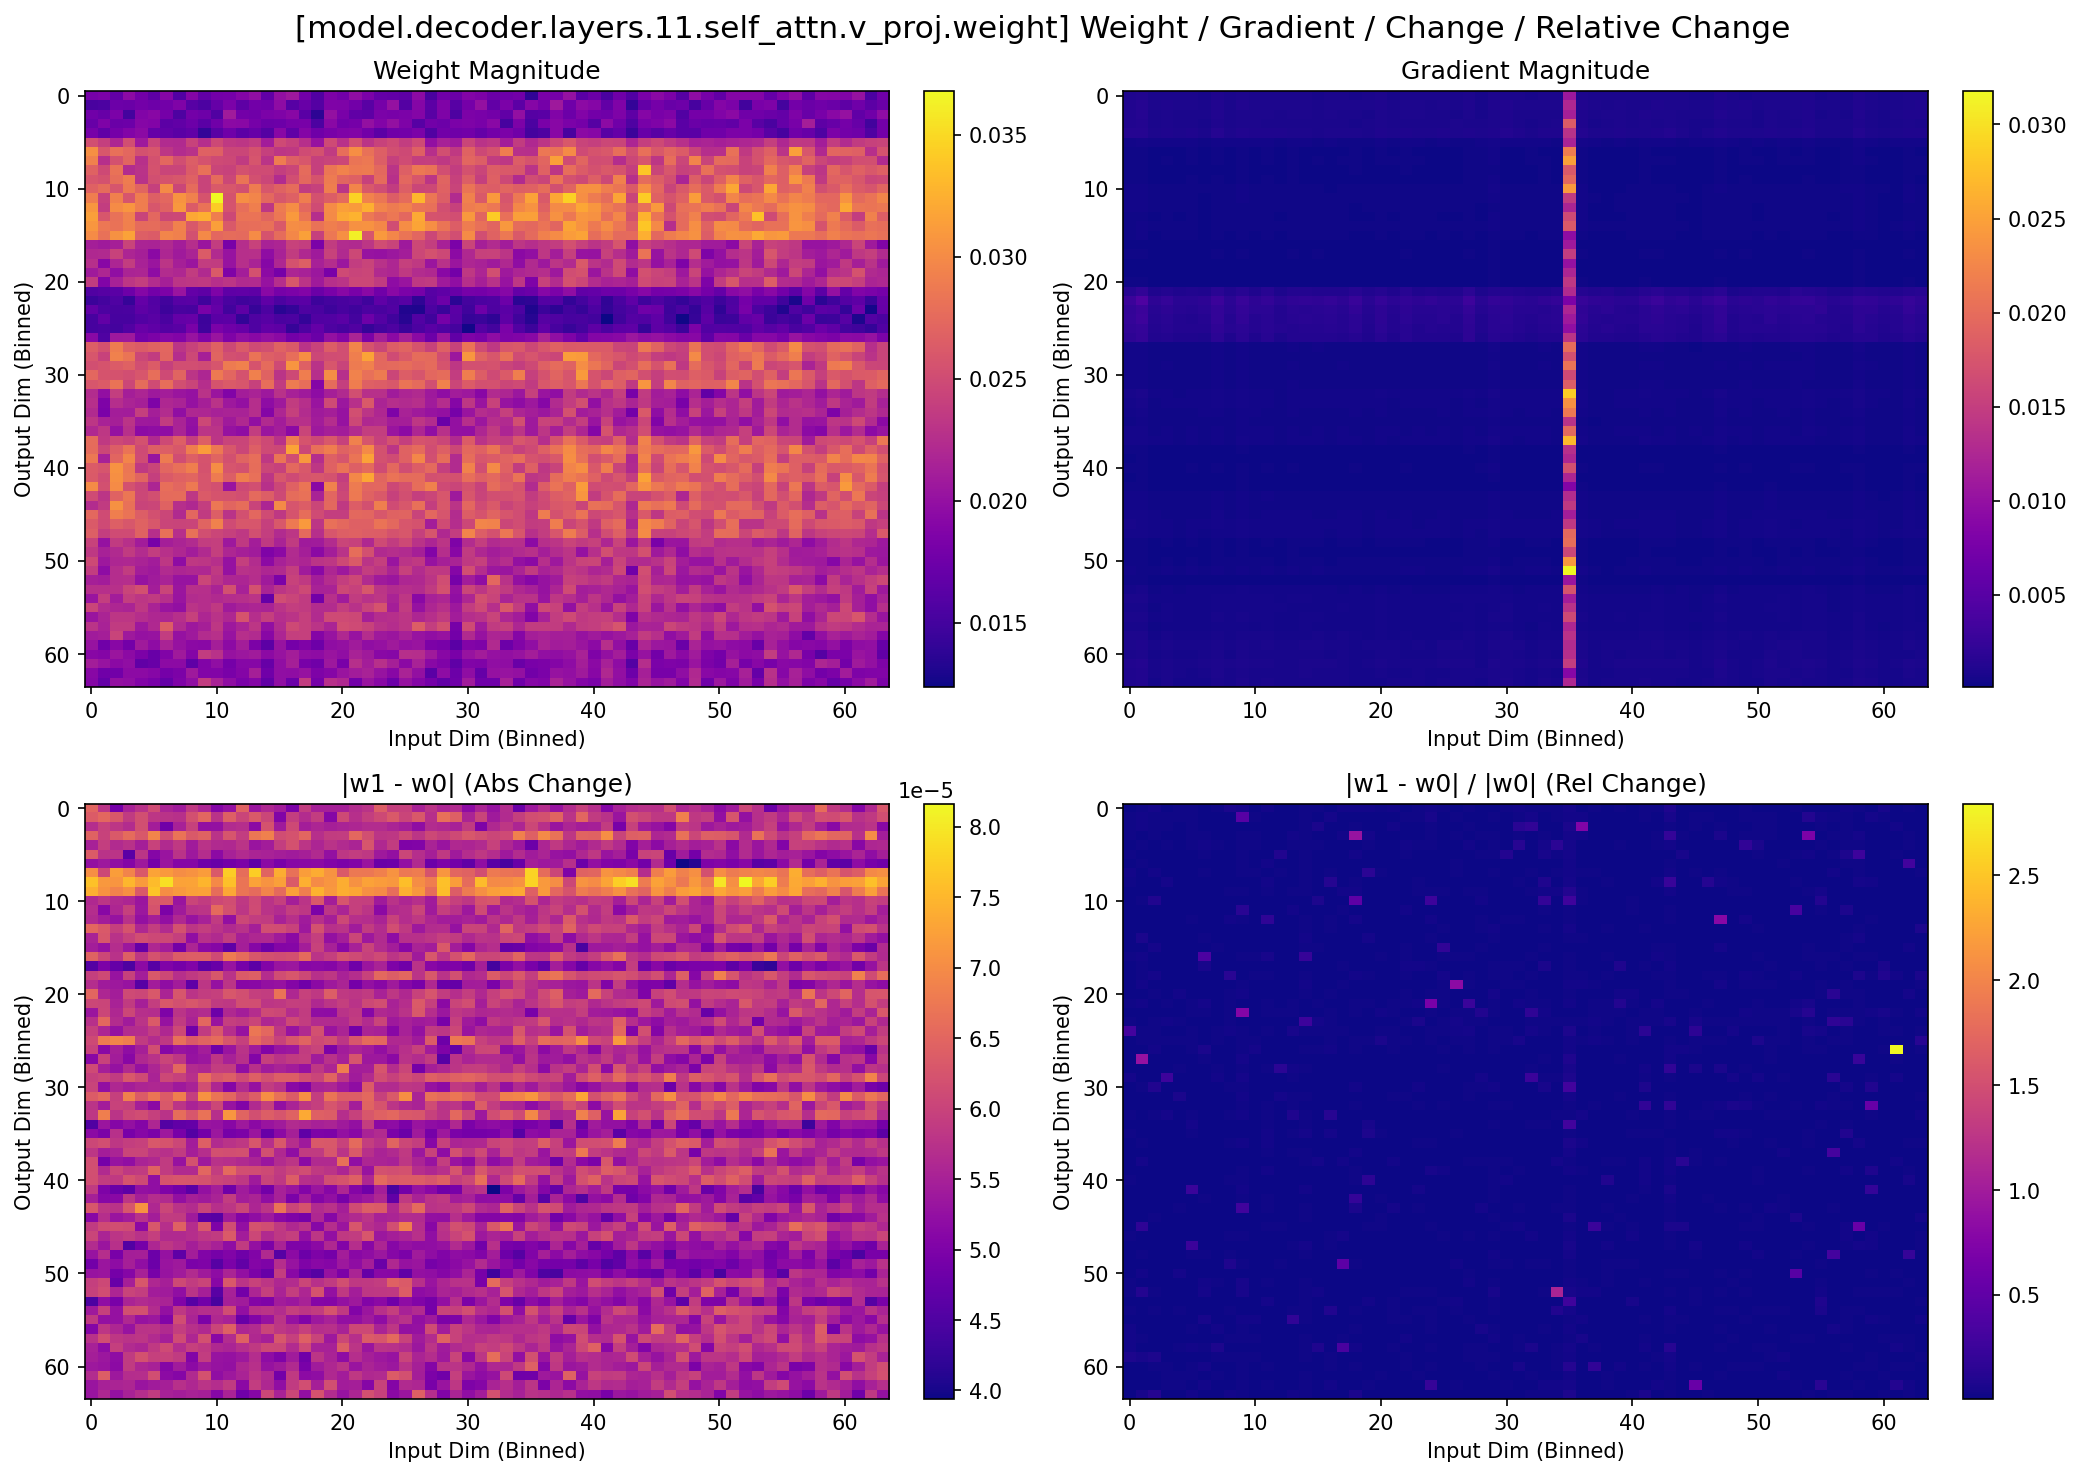

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import block_reduce
import os

def plot_heatmaps_blockreduce(
    save_dir,
    target_layer_name=None,
    bin_factor=(8, 8),
    cmap='plasma'
):
    w0 = torch.load(os.path.join(save_dir, "epoch0_layer_weights.pt"), map_location="cpu")
    w1 = torch.load(os.path.join(save_dir, "epoch1_layer_weights.pt"), map_location="cpu")
    g0 = torch.load(os.path.join(save_dir, "epoch0_layer_gradients.pt"), map_location="cpu")

    target_layers = [target_layer_name] if target_layer_name else w0.keys()

    for name in target_layers:
        if name not in w0 or name not in w1 or name not in g0:
            print(f"[SKIP] {name} (not found in one of weight0, weight1, grad0)")
            continue

        weight0 = w0[name].abs().numpy()
        weight1 = w1[name].abs().numpy()
        grad0 = g0[name].abs().numpy()

        if weight0.ndim != 2 or grad0.ndim != 2:
            print(f"[SKIP] {name} (not 2D)")
            continue

        delta = np.abs(weight1 - weight0)
        rel_change = delta / (np.abs(weight0) + 1e-8)

        # Binning
        weight_binned = block_reduce(weight0, block_size=bin_factor, func=np.mean)
        grad_binned = block_reduce(grad0, block_size=bin_factor, func=np.mean)
        delta_binned = block_reduce(delta, block_size=bin_factor, func=np.mean)
        rel_binned = block_reduce(rel_change, block_size=bin_factor, func=np.mean)

        # Plot 2x2
        fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)

        ims = [
            (weight_binned, "Weight Magnitude"),
            (grad_binned, "Gradient Magnitude"),
            (delta_binned, "|w1 - w0| (Abs Change)"),
            (rel_binned, "|w1 - w0| / |w0| (Rel Change)")
        ]

        for ax, (data, title) in zip(axes.flat, ims):
            im = ax.imshow(data, aspect='auto', cmap=cmap)
            ax.set_title(title)
            ax.set_xlabel("Input Dim (Binned)")
            ax.set_ylabel("Output Dim (Binned)")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.suptitle(f"[{name}] Weight / Gradient / Change / Relative Change", fontsize=15)
        plt.tight_layout()
        plt.show()

plot_heatmaps_blockreduce(
    save_dir="parameters/Copa/fft-1e-5-10283",
    target_layer_name="model.decoder.layers.11.self_attn.v_proj.weight",
    bin_factor=(12, 12),
    cmap='plasma'
)

/tmp/ipykernel_526279/2626695073.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc="upper right")
/tmp/ipykernel_526279/2626695073.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(loc="upper right")


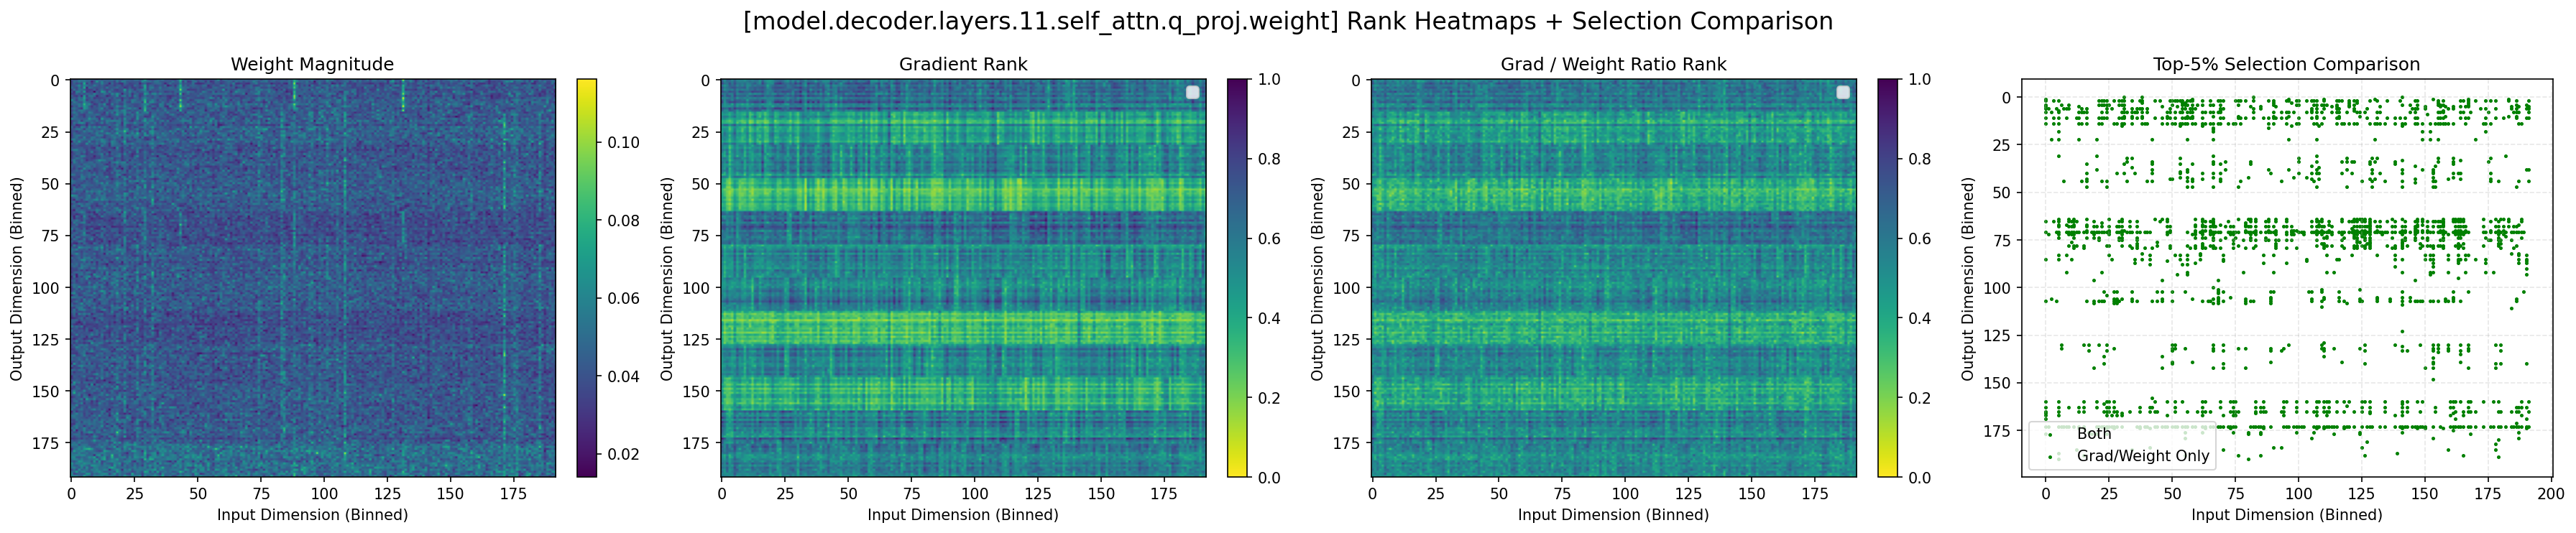

In [23]:
# Rank based heatmap

import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import block_reduce

# ✅ 설정
task = "Copa"
tag = "fft-1e-5-10283"
epoch = 0
layer_name = "model.decoder.layers.11.self_attn.q_proj.weight"
weight_path = f"parameters/{task}/{tag}/epoch{epoch}_layer_weights.pt"
grad_path   = f"parameters/{task}/{tag}/epoch{epoch}_layer_gradients.pt"

bin_factor = (4, 4)
top_percent = 0.05  # top 5%

# ✅ 로드
weights = torch.load(weight_path, map_location="cpu")[layer_name]
grads = torch.load(grad_path, map_location="cpu")[layer_name]

# ✅ 계산
weight_mag = weights.abs().numpy()
grad_mag = grads.abs().numpy()
ratio = grad_mag / (weight_mag + 1e-8)

# ✅ 랭크 함수
def to_rank_matrix(matrix):
    flat = matrix.flatten()
    ranks = flat.argsort().argsort().astype(np.float32)
    return (ranks / ranks.max()).reshape(matrix.shape)

# ✅ rank 변환
weight_rank = to_rank_matrix(weight_mag)
grad_rank = to_rank_matrix(grad_mag)
ratio_rank = to_rank_matrix(ratio)

# ✅ Binning
weight_binned = block_reduce(weight_rank, block_size=bin_factor, func=np.mean)
grad_binned = block_reduce(grad_rank, block_size=bin_factor, func=np.mean)
ratio_binned = block_reduce(ratio_rank, block_size=bin_factor, func=np.mean)

# ✅ Top-k 마스크 함수
def get_topk_mask(rank_matrix, top_percent):
    threshold = np.quantile(rank_matrix, 1 - top_percent)
    return rank_matrix >= threshold

grad_mask = get_topk_mask(grad_binned, top_percent)
ratio_mask = get_topk_mask(ratio_binned, top_percent)

# ✅ 교집합 및 차집합 계산
intersection_mask = grad_mask & ratio_mask
grad_only_mask = grad_mask & ~ratio_mask
ratio_only_mask = ratio_mask & ~grad_mask

# ✅ 위치 추출
y_inter, x_inter = np.where(intersection_mask)
y_grad, x_grad = np.where(grad_only_mask)
y_ratio, x_ratio = np.where(ratio_only_mask)

# ✅ 시각화 (4개 subplot)
fig, axes = plt.subplots(1, 4, figsize=(24, 5), dpi=150)

# 1. Weight Rank (개별 스케일)
weight_mag_binned = block_reduce(weight_mag, block_size=bin_factor, func=np.mean)
im0 = axes[0].imshow(weight_mag_binned, aspect='auto', cmap='viridis')
axes[0].set_title("Weight Magnitude")
# weight_norm = (weight_mag - weight_mag.min()) / (weight_mag.max() - weight_mag.min() + 1e-8)
# weight_norm_binned = block_reduce(weight_norm, block_size=bin_factor, func=np.mean)
# im0 = axes[0].imshow(weight_norm_binned, aspect='auto', cmap='viridis_r')
# axes[0].set_title("Normalized Weight Magnitude")

axes[0].set_xlabel("Input Dimension (Binned)")
axes[0].set_ylabel("Output Dimension (Binned)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# 2. Gradient Rank (공통 스케일 + 마스크)
im1 = axes[1].imshow(grad_binned, aspect='auto', cmap='viridis_r', vmin=0, vmax=1)
axes[1].set_title("Gradient Rank")
axes[1].set_xlabel("Input Dimension (Binned)")
axes[1].set_ylabel("Output Dimension (Binned)")
y1, x1 = np.where(grad_mask)
#axes[1].scatter(x1, y1, color='red', s=3, label=f"Top {int(top_percent*100)}%")
axes[1].legend(loc="upper right")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# 3. Grad/Weight Rank (공통 스케일 + 마스크)
im2 = axes[2].imshow(ratio_binned, aspect='auto', cmap='viridis_r', vmin=0, vmax=1)
axes[2].set_title("Grad / Weight Ratio Rank")
axes[2].set_xlabel("Input Dimension (Binned)")
axes[2].set_ylabel("Output Dimension (Binned)")
y2, x2 = np.where(ratio_mask)
#axes[2].scatter(x2, y2, color='red', s=3, label=f"Top {int(top_percent*100)}%")
axes[2].legend(loc="upper right")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# 4. Selection Comparison (산점도만)
axes[3].scatter(x_inter, y_inter, c='green', s=2, label='Both')
#axes[3].scatter(x_grad, y_grad, c='green', s=2, label='Gradient Only')
axes[3].scatter(x_ratio, y_ratio, c='green', s=2, label='Grad/Weight Only')
axes[3].set_title(f"Top-{int(top_percent*100)}% Selection Comparison")
axes[3].set_xlabel("Input Dimension (Binned)")
axes[3].set_ylabel("Output Dimension (Binned)")
axes[3].invert_yaxis()
axes[3].legend()
axes[3].grid(True, linestyle='--', alpha=0.3)

# ✅ 전체 타이틀 및 마무리
plt.suptitle(f"[{layer_name}] Rank Heatmaps + Selection Comparison", fontsize=16)
plt.tight_layout()
plt.show()


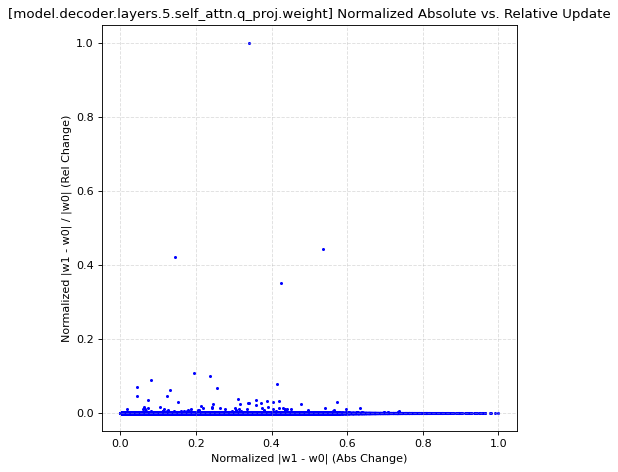

Mean Relative Update: 0.015275  →  1.53%


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_relative_update_scatter(
    save_dir,
    target_layer_name=None
):
    # ✅ Load weights and gradients
    w0 = torch.load("parameters/pretrained_weights.pt", map_location="cpu")
    w1 = torch.load(os.path.join(save_dir, "epoch1_layer_weights.pt"), map_location="cpu")
    g0 = torch.load(os.path.join(save_dir, "epoch0_layer_gradients.pt"), map_location="cpu")

    target_layers = [target_layer_name] if target_layer_name else w0.keys()

    for name in target_layers:
        if name not in w0 or name not in w1 or name not in g0:
            print(f"[SKIP] {name} (not found in one of weight0, weight1, grad0)")
            continue

        weight0 = w0[name].abs().numpy()
        weight1 = w1[name].abs().numpy()

        if weight0.ndim != 2:
            print(f"[SKIP] {name} (not 2D)")
            continue

        # ✅ Compute absolute & relative update
        delta = np.abs(weight1 - weight0)
        rel_change = delta / (np.abs(weight0) + 1e-8)

        # ✅ Flatten for scatter plot
        flat_delta = delta.flatten()
        flat_rel = rel_change.flatten()

        # ✅ Min-max normalization
        norm_delta = (flat_delta - flat_delta.min()) / (flat_delta.max() - flat_delta.min() + 1e-12)
        norm_rel = (flat_rel - flat_rel.min()) / (flat_rel.max() - flat_rel.min() + 1e-12)

        # ✅ Scatter plot
        plt.figure(figsize=(6, 6), dpi=80)
        plt.scatter(norm_delta, norm_rel, alpha=1, s=3, c='blue')
        plt.xlabel("Normalized |w1 - w0| (Abs Change)")
        plt.ylabel("Normalized |w1 - w0| / |w0| (Rel Change)")
        plt.title(f"[{name}] Normalized Absolute vs. Relative Update")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()
        
        mean_rel_update = np.mean(np.abs(weight1 - weight0) / (np.abs(weight0) + 1e-8))
        percent_change = mean_rel_update * 100
        print(f"Mean Relative Update: {mean_rel_update:.6f}  →  {percent_change:.2f}%")


# ✅ 실행 예시
plot_relative_update_scatter(
    save_dir="parameters/Copa/fft-1e-5-10283",
    target_layer_name="model.decoder.layers.5.self_attn.q_proj.weight"
)

Percentage of parameters with < 1% relative update: 83.15%


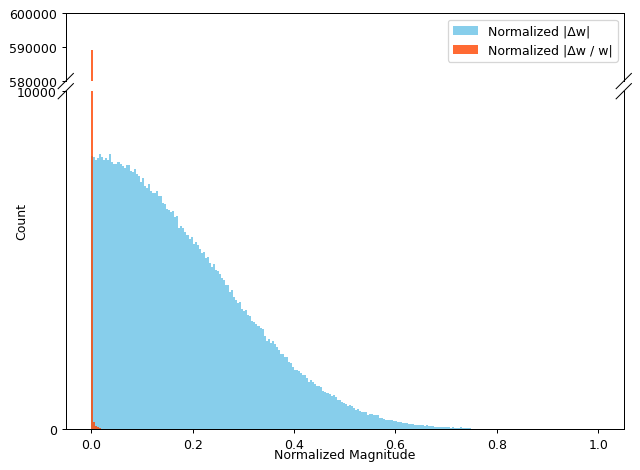

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from brokenaxes import brokenaxes
import seaborn as sns
import os

def visualize_relative_update_distribution(
    save_dir,
    target_layer_name="model.decoder.layers.11.self_attn.q_proj.weight"
):
    # ✅ Load weights and gradients
    w0 = torch.load("parameters/pretrained_weights.pt", map_location="cpu")
    w1 = torch.load(os.path.join(save_dir, "epoch1_layer_weights.pt"), map_location="cpu")
    g0 = torch.load(os.path.join(save_dir, "epoch0_layer_gradients.pt"), map_location="cpu")

    if target_layer_name not in w0 or target_layer_name not in w1:
        print(f"[SKIP] Layer '{target_layer_name}' not found.")
        return

    weight0 = w0[target_layer_name].abs().numpy()
    weight1 = w1[target_layer_name].abs().numpy()

    delta = np.abs(weight1 - weight0)
    rel_change = delta / (np.abs(weight0) + 1e-8)

    flat_delta = delta.flatten()
    flat_rel = rel_change.flatten()

    # ✅ 1. Histogram Overlay: Absolute vs. Relative Update
    # ✅ Histogram 계산
    bins = 250
    delta_norm = (flat_delta - flat_delta.min()) / (flat_delta.max() - flat_delta.min() + 1e-8)
    rel_norm = (flat_rel - flat_rel.min()) / (flat_rel.max() - flat_rel.min() + 1e-8)

    counts_abs, bins_abs = np.histogram(delta_norm, bins=bins)
    counts_rel, bins_rel = np.histogram(rel_norm, bins=bins)

    bin_width = bins_abs[1] - bins_abs[0]
    bin_centers_abs = (bins_abs[:-1] + bins_abs[1:]) / 2
    bin_centers_rel = (bins_rel[:-1] + bins_rel[1:]) / 2

    fig = plt.figure(figsize=(8, 6), dpi=90)
    bax = brokenaxes(
        ylims=((0, 10000), (580000, 600000)),
        hspace=0.05,
        d=0.015,
        despine=False,
        fig=fig,
        height_ratios=(1, 5)
    )

    bax.bar(bin_centers_abs, counts_abs, width=bin_width, color='skyblue', label="Normalized |Δw|")
    bax.bar(bin_centers_rel, counts_rel, width=bin_width, color='orangered', alpha=0.8, label="Normalized |Δw / w|")

    bax.set_xlabel("Normalized Magnitude")
    bax.set_ylabel("Count")

    # ✅ legend 수동으로 아래쪽 subplot에 지정
    bax.axs[0].legend(loc='upper right')

    # ✅ 제목
    # fig.suptitle("Histogram of Normalized Absolute vs. Relative Updates", fontsize=14)


    # # ✅ 2. CDF Plot of Relative Update
    # sorted_vals = np.sort(flat_rel)
    # cdf = np.linspace(0, 1, len(sorted_vals))

    # plt.figure(figsize=(6, 4), dpi=120)
    # plt.plot(sorted_vals * 100, cdf, label="CDF of |Δw / w|")
    # plt.axvline(1.0, color='red', linestyle='--', label="1% Threshold")
    # plt.xlabel("Relative Update (%)")
    # plt.ylabel("Cumulative Proportion")
    # plt.title("CDF: Relative Parameter Change")
    # plt.legend()
    # plt.grid(True, linestyle="--", alpha=0.4)
    # plt.tight_layout()
    # plt.show()

    # # ✅ 3. Histogram + KDE: Relative Update
    # plt.figure(figsize=(6, 4), dpi=120)
    # sns.kdeplot(flat_rel, bw_adjust=0.5, label="KDE of |Δw / w|", color='darkgreen')
    # plt.hist(flat_rel, bins=100, alpha=0.3, density=True, label='Histogram', color='lightgreen')
    # plt.xlabel("Relative Update")
    # plt.ylabel("Density")
    # plt.title("Histogram & KDE: Relative Update")
    # plt.legend()
    # plt.grid(True, linestyle='--', alpha=0.4)
    # plt.tight_layout()
    # plt.show()

    # ✅ 수치 요약 출력
    threshold = 0.01  # 1%
    below_threshold = np.mean(flat_rel < threshold)
    print(f"Percentage of parameters with < 1% relative update: {below_threshold * 100:.2f}%")

# ✅ 실행 예시
visualize_relative_update_distribution(
    save_dir="parameters/Copa/fft-1e-5-10283",
    target_layer_name="model.decoder.layers.11.self_attn.v_proj.weight"
)


Max count (|Δw|): 218640
Max count (|Δw / w|): 14154980
Percentage of parameters with < 1% relative update: 83.51%


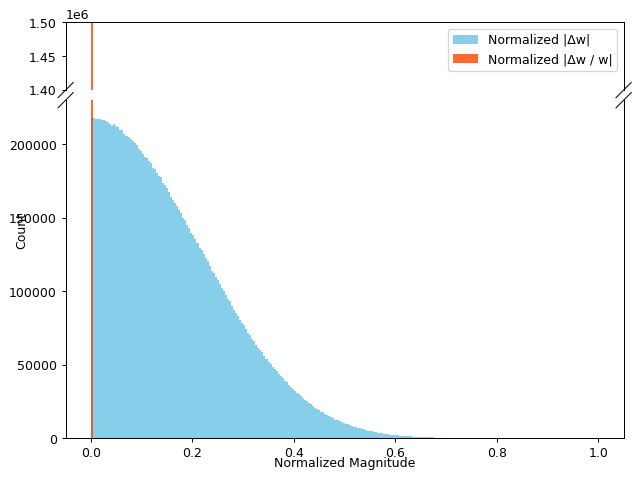

In [7]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from brokenaxes import brokenaxes

def visualize_relative_update_distribution_all_layers(
    save_dir,
    pretrained_path="parameters/pretrained_weights.pt",
    epoch_name="epoch1_layer_weights.pt"
):
    # ✅ Load weights
    w0 = torch.load(pretrained_path, map_location="cpu")
    w1 = torch.load(os.path.join(save_dir, epoch_name), map_location="cpu")

    flat_deltas = []
    flat_rels = []

    for layer in range(12):
        for proj in ["q_proj", "v_proj"]:
            key = f"model.decoder.layers.{layer}.self_attn.{proj}.weight"
            if key not in w0 or key not in w1:
                print(f"[SKIP] {key}")
                continue

            weight0 = w0[key].abs().numpy()
            weight1 = w1[key].abs().numpy()

            delta = np.abs(weight1 - weight0)
            rel_change = delta / (np.abs(weight0) + 1e-8)

            flat_deltas.append(delta.flatten())
            flat_rels.append(rel_change.flatten())

    # ✅ Flatten 전체
    flat_delta = np.concatenate(flat_deltas)
    flat_rel = np.concatenate(flat_rels)

    # ✅ Normalize
    bins = 250
    delta_norm = (flat_delta - flat_delta.min()) / (flat_delta.max() - flat_delta.min() + 1e-8)
    rel_norm = (flat_rel - flat_rel.min()) / (flat_rel.max() - flat_rel.min() + 1e-8)

    counts_abs, bins_abs = np.histogram(delta_norm, bins=bins)
    counts_rel, bins_rel = np.histogram(rel_norm, bins=bins)

    # ✅ 최대값 확인
    print(f"Max count (|Δw|): {counts_abs.max()}")
    print(f"Max count (|Δw / w|): {counts_rel.max()}")

    bin_width = bins_abs[1] - bins_abs[0]
    bin_centers_abs = (bins_abs[:-1] + bins_abs[1:]) / 2
    bin_centers_rel = (bins_rel[:-1] + bins_rel[1:]) / 2

    # ✅ Plot with broken axes
    fig = plt.figure(figsize=(8, 6), dpi=90)
    bax = brokenaxes(
        ylims=((0, 230000), (1400000, 1500000)),
        hspace=0.05,
        d=0.015,
        despine=False,
        fig=fig,
        height_ratios=(1, 5)
    )

    bax.bar(bin_centers_abs, counts_abs, width=bin_width, color='skyblue', label="Normalized |Δw|")
    bax.bar(bin_centers_rel, counts_rel, width=bin_width, color='orangered', alpha=0.8, label="Normalized |Δw / w|")

    bax.set_xlabel("Normalized Magnitude")
    bax.set_ylabel("Count")
    bax.axs[0].legend(loc='upper right')

    # ✅ 수치 요약
    threshold = 0.01
    below_threshold = np.mean(flat_rel < threshold)
    print(f"Percentage of parameters with < 1% relative update: {below_threshold * 100:.2f}%")

# ✅ 실행 예시
visualize_relative_update_distribution_all_layers(
    save_dir="parameters/Copa/fft-1e-5-10283"
)


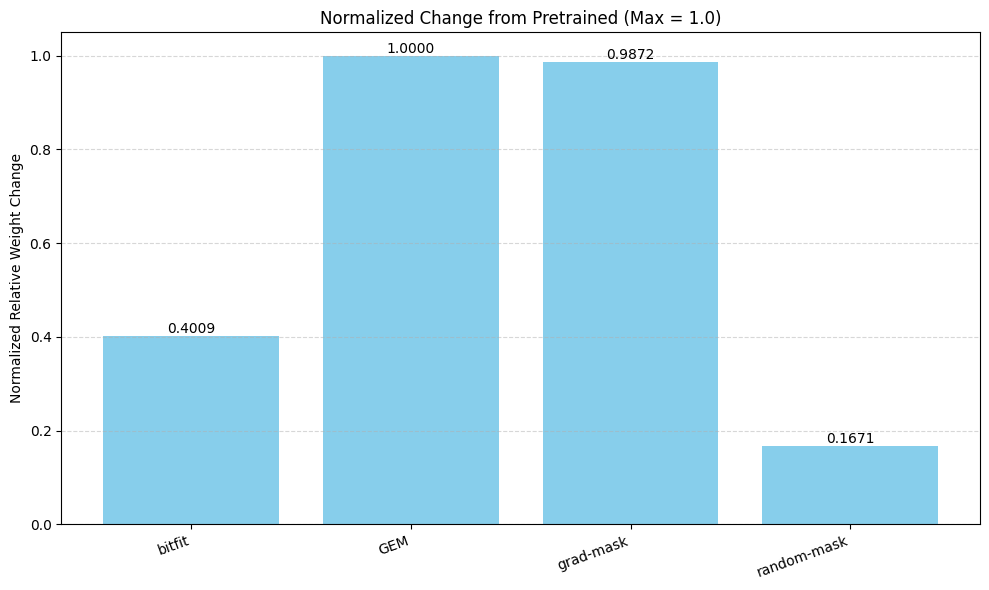

In [26]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ✅ 공통 구조의 key mapping
shared_key_remap = {
    "q_proj": {
        "weight": {
            "base": "q_proj.base_Linear.weight",
            "tunable": "q_proj.tunable_weight",
            "pretrained": "q_proj.weight"
        },
        "bias": {
            "base": "q_proj.base_Linear.bias",
            "pretrained": "q_proj.bias"
        }
    },
    "v_proj": {
        "weight": {
            "base": "v_proj.base_Linear.weight",
            "tunable": "v_proj.tunable_weight",
            "pretrained": "v_proj.weight"
        },
        "bias": {
            "base": "v_proj.base_Linear.bias",
            "pretrained": "v_proj.bias"
        }
    }
}

method_key_remap = {
    "bitfit": shared_key_remap,
    "GEM": shared_key_remap,
    "grad-mask": shared_key_remap,
    "random-mask": shared_key_remap
}

method_to_folder = {
    "bitfit": "bitfit-1e-5-8274",
    "GEM": "entropy_gradweight_masking_0.999-1e-5-8274",
    "grad-mask": "gradient_masking_0.999-1e-5-8274",
    "random-mask": "random_masking_0.999-1e-3-8274"
}

base_dir = "parameters/Copa"
pretrained_path = "parameters/opt125m_pretrained_weights.pt"
epoch_name = "epoch20_layer_weights.pt"
layers = list(range(12))

def compute_total_relative_change(w_ref, w_new):
    """Element-wise total relative change"""
    w_ref_np = w_ref.detach().cpu().numpy()
    w_new_np = w_new.detach().cpu().numpy()
    delta = np.abs(w_new_np - w_ref_np)
    denom = np.abs(w_ref_np) + 1e-8
    rel_change = delta / denom
    return rel_change.sum(), rel_change.size

method_changes = {}

# ✅ pretrained weights load
pretrained_weights = torch.load(pretrained_path, map_location="cpu")

# ✅ iterate over methods
for method, folder in method_to_folder.items():
    path_epoch = os.path.join(base_dir, folder, epoch_name)
    if not os.path.exists(path_epoch):
        print(f"❌ Missing weights for {method}")
        continue

    method_weights = torch.load(path_epoch, map_location="cpu")
    total_rel_change, total_param_count = 0.0, 0

    for layer in layers:
        for proj in ["q_proj", "v_proj"]:
            remap = method_key_remap[method][proj]

            # ✅ weight 비교: (base + tunable) vs pretrained
            try:
                base_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['base']}"
                tunable_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['tunable']}"
                pretrained_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['pretrained']}"

                base_weight = method_weights[base_key]
                tunable_weight = method_weights[tunable_key]
                effective_weight = base_weight + tunable_weight
                pretrained_weight = pretrained_weights[pretrained_key]

                rel_sum, n_elem = compute_total_relative_change(pretrained_weight, effective_weight)
                total_rel_change += rel_sum
                total_param_count += n_elem
            except KeyError:
                print(f"[SKIP] {method} - weight key missing at layer {layer}, {proj}")
                continue

            # ✅ bias 비교
            try:
                base_bias_key = f"model.decoder.layers.{layer}.self_attn.{remap['bias']['base']}"
                pretrained_bias_key = f"model.decoder.layers.{layer}.self_attn.{remap['bias']['pretrained']}"

                base_bias = method_weights[base_bias_key]
                pretrained_bias = pretrained_weights[pretrained_bias_key]

                rel_sum, n_elem = compute_total_relative_change(pretrained_bias, base_bias)
                total_rel_change += rel_sum
                total_param_count += n_elem
            except KeyError:
                print(f"[SKIP] {method} - bias key missing at layer {layer}, {proj}")
                continue

    method_changes[method] = total_rel_change / total_param_count if total_param_count > 0 else 0.0

# ✅ Normalize
max_value = max(method_changes.values()) if method_changes else 1.0
normalized_changes = {k: v / max_value for k, v in method_changes.items()}

# ✅ 시각화
plt.figure(figsize=(10, 6))
labels = list(normalized_changes.keys())
normalized_values = [normalized_changes[m] for m in labels]
bars = plt.bar(labels, normalized_values, color="skyblue")

plt.ylabel("Normalized Relative Weight Change")
plt.title("Normalized Change from Pretrained (Max = 1.0)")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# ✅ bar 위에 normalized 수치 표시
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.4f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [30]:
import os
import torch

method_to_folder = {
    "fft": "fft-1e-5-28",
}

base_dir = "parameters/RTE_125m"
epochX_name = "epoch10_layer_weights.pt"

for method, folder in method_to_folder.items():
    path = os.path.join(base_dir, folder, epochX_name)
    print(f"\n🔍 Keys in {method}:")
    if os.path.exists(path):
        state_dict = torch.load(path, map_location="cpu")
        for i, key in enumerate(state_dict.keys()):
            print(f"{i:03d}: {key}")
            if i > 50:
                print("... (truncated)")
                break
    else:
        print("❌ File not found.")



🔍 Keys in fft:
000: model.decoder.layers.0.self_attn.v_proj.weight
001: model.decoder.layers.0.self_attn.v_proj.bias
002: model.decoder.layers.0.self_attn.q_proj.weight
003: model.decoder.layers.0.self_attn.q_proj.bias
004: model.decoder.layers.1.self_attn.v_proj.weight
005: model.decoder.layers.1.self_attn.v_proj.bias
006: model.decoder.layers.1.self_attn.q_proj.weight
007: model.decoder.layers.1.self_attn.q_proj.bias
008: model.decoder.layers.2.self_attn.v_proj.weight
009: model.decoder.layers.2.self_attn.v_proj.bias
010: model.decoder.layers.2.self_attn.q_proj.weight
011: model.decoder.layers.2.self_attn.q_proj.bias
012: model.decoder.layers.3.self_attn.v_proj.weight
013: model.decoder.layers.3.self_attn.v_proj.bias
014: model.decoder.layers.3.self_attn.q_proj.weight
015: model.decoder.layers.3.self_attn.q_proj.bias
016: model.decoder.layers.4.self_attn.v_proj.weight
017: model.decoder.layers.4.self_attn.v_proj.bias
018: model.decoder.layers.4.self_attn.q_proj.weight
019: model.dec

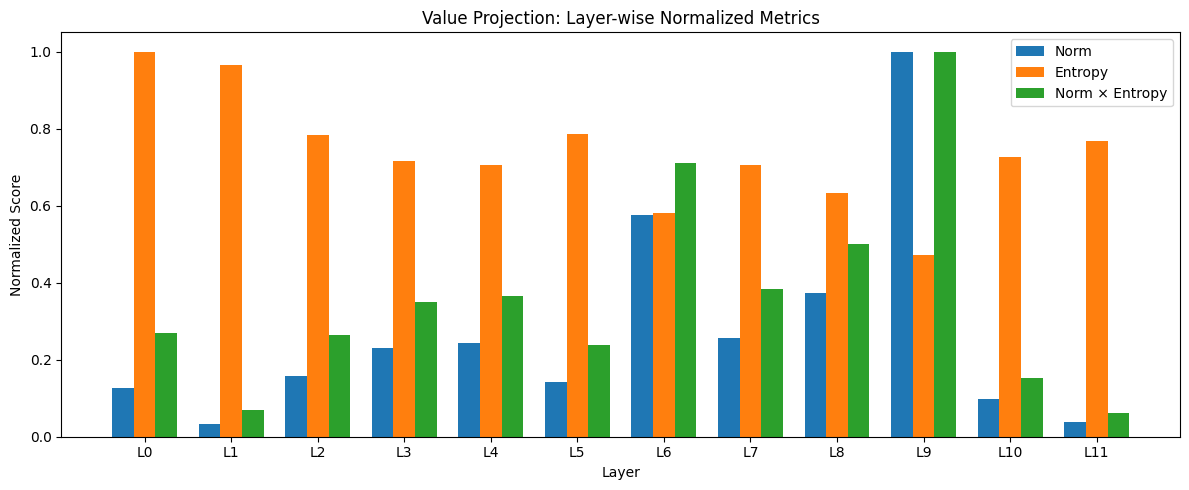

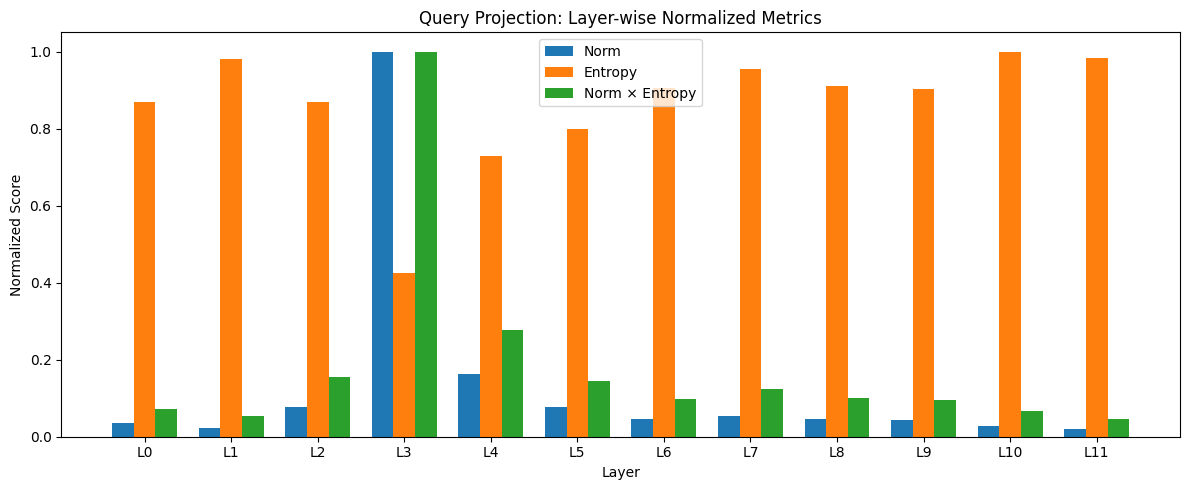

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 정의
layer_names = [f"L{l}" for l in range(12)]
v_proj_norms = [168155.625, 44610.77, 209681.73, 305953.09, 324020.28, 190263.81, 764875.19, 339803.0, 494486.81, 1328135.5, 130254.34, 50929.66]
q_proj_norms = [2383.36, 1561.44, 5069.71, 66551.13, 10787.42, 5091.30, 3048.31, 3657.95, 3095.60, 2949.67, 1906.14, 1332.50]
v_proj_entropy = [8.3204, 8.0358, 6.5227, 5.9585, 5.8660, 6.5317, 4.8335, 5.8658, 5.2695, 3.9157, 6.0447, 6.3881]
q_proj_entropy = [7.8371, 8.8586, 7.8411, 3.8349, 6.5865, 7.2003, 8.1631, 8.6119, 8.2057, 8.1412, 9.0224, 8.8646]

# importance score 계산
v_proj_scores = np.array(v_proj_norms) * np.array(v_proj_entropy)
q_proj_scores = np.array(q_proj_norms) * np.array(q_proj_entropy)

# 정규화
v_proj_normed_norms = np.array(v_proj_norms) / np.max(v_proj_norms)
v_proj_normed_entropy = np.array(v_proj_entropy) / np.max(v_proj_entropy)
v_proj_normed_scores = v_proj_scores / np.max(v_proj_scores)

q_proj_normed_norms = np.array(q_proj_norms) / np.max(q_proj_norms)
q_proj_normed_entropy = np.array(q_proj_entropy) / np.max(q_proj_entropy)
q_proj_normed_scores = q_proj_scores / np.max(q_proj_scores)

# 시각화 설정
x = np.arange(len(layer_names))
width = 0.25

# Value Projection
plt.figure(figsize=(12, 5))
plt.bar(x - width, v_proj_normed_norms, width, label='Norm', color="#1f77b4")         # 파랑
plt.bar(x, v_proj_normed_entropy, width, label='Entropy', color="#ff7f0e")            # 주황
plt.bar(x + width, v_proj_normed_scores, width, label='Norm × Entropy', color="#2ca02c")  # 초록
plt.xticks(x, layer_names)
plt.ylabel("Normalized Score")
plt.xlabel("Layer")
plt.title("Value Projection: Layer-wise Normalized Metrics")
plt.legend()
plt.tight_layout()
plt.show()

# Query Projection
plt.figure(figsize=(12, 5))
plt.bar(x - width, q_proj_normed_norms, width, label='Norm', color="#1f77b4")
plt.bar(x, q_proj_normed_entropy, width, label='Entropy', color="#ff7f0e")
plt.bar(x + width, q_proj_normed_scores, width, label='Norm × Entropy', color="#2ca02c")
plt.xticks(x, layer_names)
plt.ylabel("Normalized Score")
plt.xlabel("Layer")
plt.title("Query Projection: Layer-wise Normalized Metrics")
plt.legend()
plt.tight_layout()
plt.show()


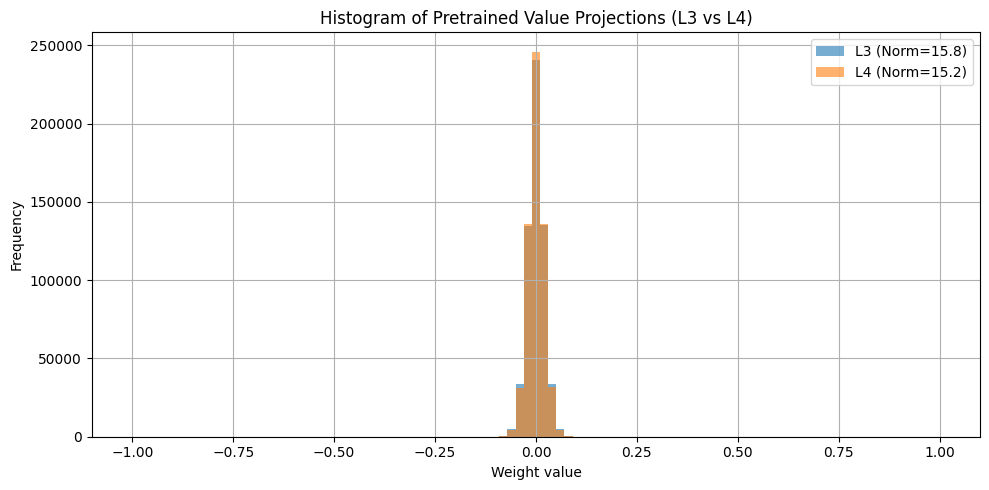

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# 설정
pretrained_path = "parameters/opt125m_pretrained_weights.pt"
v_proj_template = "model.decoder.layers.{}.self_attn.v_proj.weight"
layers_to_compare = [3, 4]

# pretrained weights 불러오기
pretrained_weights = torch.load(pretrained_path, map_location="cpu")
weights = {}
for layer in layers_to_compare:
    name = v_proj_template.format(layer)
    w = pretrained_weights[name]
    weights[layer] = w.flatten().numpy()

# 히스토그램 시각화
plt.figure(figsize=(10, 5))
bins = np.linspace(-1, 1, 100)
for layer in layers_to_compare:
    plt.hist(weights[layer], bins=bins, alpha=0.6, label=f"L{layer} (Norm={np.linalg.norm(weights[layer]):.1f})")

plt.title("Histogram of Pretrained Value Projections (L3 vs L4)")
plt.xlabel("Weight value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

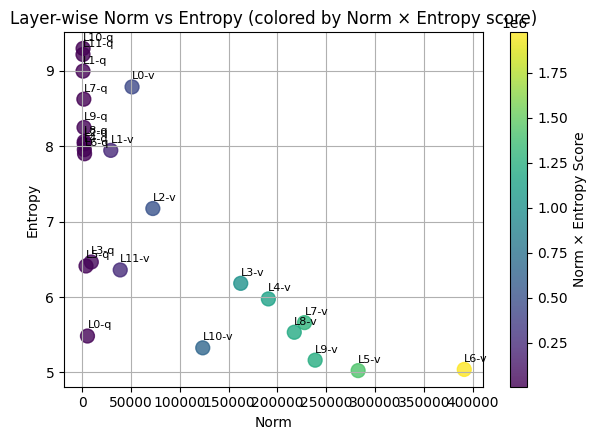

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 수작업 정리된 데이터 (이전에 너가 줬던 값 그대로)
layer_ids = [f"L{i}" for i in range(12)] * 2
proj_type = ["v"] * 12 + ["q"] * 12

# data from RTE 125m
norms = [
    50967.23046875, 29149.916015625, 72268.40625, 162348.65625, 190673.625, 282664.375,
    391429.84375, 227716.953125, 217227.734375, 238612.453125, 123425.0625, 38835.00390625,
    5266.296875, 725.1656494140625, 1984.0184326171875, 9205.119140625, 2055.94873046875,
    3782.913330078125, 2291.495361328125, 1553.11474609375, 1941.1944580078125, 1721.2166748046875,
    783.9954833984375, 680.079345703125
]
entropy = [
    8.78756332397461, 7.945693492889404, 7.174533843994141, 6.182312488555908, 5.975659370422363,
    5.024828910827637, 5.040435791015625, 5.661337852478027, 5.5334978103637695, 5.1633405685424805,
    5.326933860778809, 6.359867095947266, 5.48358154296875, 8.99644947052002, 8.032772064208984,
    6.465005874633789, 7.955657958984375, 6.412325859069824, 7.900918960571289, 8.624792098999023,
    8.061515808105469, 8.249553680419922, 9.29750919342041, 9.216986656188965
]
score = np.array(norms) * np.array(entropy)

# 시각화
plt.figure(figsize=(6, 4.5))
scatter = plt.scatter(norms, entropy, c=score, cmap='viridis', s=100, alpha=0.8)
for i in range(len(layer_ids)):
    plt.text(norms[i], entropy[i]+0.1, f"{layer_ids[i]}-{proj_type[i]}", fontsize=8)

plt.xlabel("Norm")
plt.ylabel("Entropy")
plt.title("Layer-wise Norm vs Entropy (colored by Norm × Entropy score)")
cbar = plt.colorbar(scatter)
cbar.set_label("Norm × Entropy Score")
plt.grid(True)
plt.tight_layout()
plt.show()


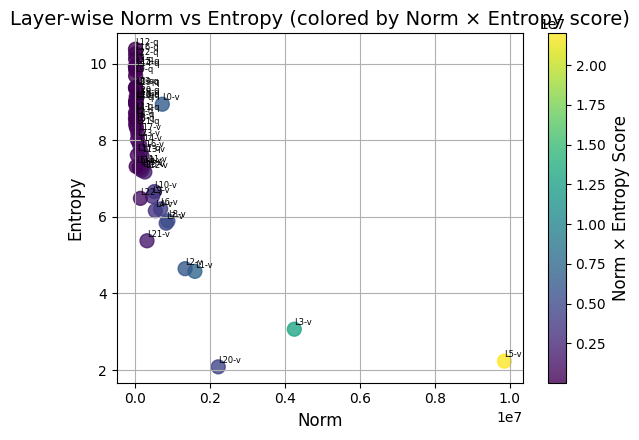

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ✅ Layer, Projection 이름 세팅
layer_ids = [f"L{i}" for i in range(24)] * 2
proj_type = ["v"] * 24 + ["q"] * 24

# ✅ 새로 정리된 norms, entropy - BoolQ 1.3b
norms = [
    721588.1875, 1591538.125, 1329813.125, 4246746.5, 534918.625, 9860147.0,
    676275.125, 824830.75, 870407.625, 458611.6875, 509681.40625, 225988.328125,
    254741.734375, 176076.9375, 112307.515625, 170717.625, 146344.625, 67040.0859375,
    118950.8203125, 106587.4765625, 2215336.5, 312406.3125, 136552.15625, 57012.5,
    11815.2646484375, 6253.24560546875, 4615.32177734375, 2395.8037109375, 15653.7275390625,
    23670.17578125, 10030.1572265625, 10910.0888671875, 8284.810546875, 7434.10888671875,
    12460.49609375, 23431.681640625, 4425.92724609375, 16859.0859375, 10539.732421875,
    10847.54296875, 8229.1484375, 55014.8359375, 24739.279296875, 16307.41796875,
    24591.720703125, 29588.6796875, 6568.7216796875, 3746.429931640625
]
entropy = [
    8.943464279174805, 4.577258110046387, 4.647339820861816, 3.0662081241607666, 6.161450386047363,
    2.231943130493164, 6.2094807624816895, 5.8356828689575195, 5.893335342407227,
    6.5363664627075195, 6.6613664627075195, 7.329367160797119, 7.173451900482178,
    7.59549617767334, 7.887080192565918, 7.215226173400879, 7.716536521911621,
    8.172536849975586, 7.2600884437561035, 7.308191299438477, 2.083238363265991,
    5.376133918762207, 6.484773635864258, 8.014108657836914,
    9.376484870910645, 8.718818664550781, 8.576638221740723, 9.936233520507812,
    8.519083976745605, 7.317587852478027, 8.413301467895508, 9.003952026367188,
    8.943849563598633, 9.684789657592773, 9.004650115966797, 8.681879043579102,
    10.380302429199219, 9.019601821899414, 9.830604553222656, 9.906880378723145,
    10.258929252624512, 7.613541126251221, 9.072456359863281, 9.338296890258789,
    9.141489028930664, 8.327936172485352, 10.129844665527344, 9.376659393310547
]

# ✅ Score 계산
score = np.array(norms) * np.array(entropy)

# ✅ 시각화
plt.figure(figsize=(6, 4.5))
scatter = plt.scatter(norms, entropy, c=score, cmap='viridis', s=100, alpha=0.8)

for i in range(len(layer_ids)):
    plt.text(norms[i], entropy[i] + 0.1, f"{layer_ids[i]}-{proj_type[i]}", fontsize=6)

plt.xlabel("Norm", fontsize=12)
plt.ylabel("Entropy", fontsize=12)
plt.title("Layer-wise Norm vs Entropy (colored by Norm × Entropy score)", fontsize=14)
cbar = plt.colorbar(scatter)
cbar.set_label("Norm × Entropy Score", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


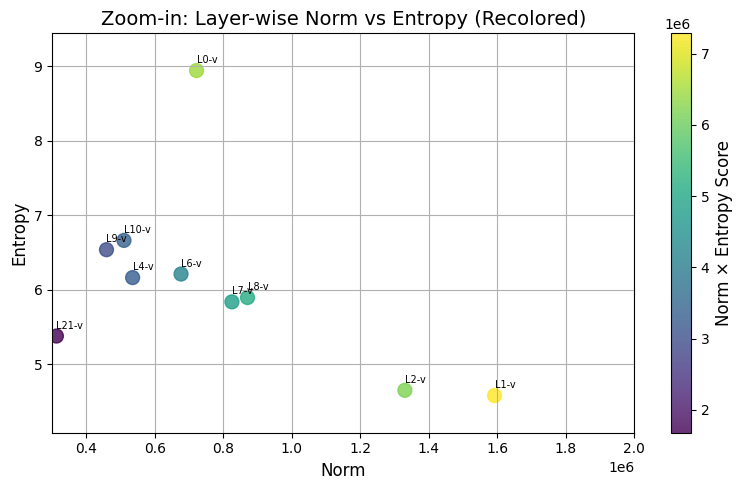

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ✅ Layer, Projection 이름 세팅
layer_ids = [f"L{i}" for i in range(24)] * 2
proj_type = ["v"] * 24 + ["q"] * 24

# ✅ 새로 정리된 norms, entropy
norms = [
    721588.1875, 1591538.125, 1329813.125, 4246746.5, 534918.625, 9860147.0,
    676275.125, 824830.75, 870407.625, 458611.6875, 509681.40625, 225988.328125,
    254741.734375, 176076.9375, 112307.515625, 170717.625, 146344.625, 67040.0859375,
    118950.8203125, 106587.4765625, 2215336.5, 312406.3125, 136552.15625, 57012.5,
    11815.2646484375, 6253.24560546875, 4615.32177734375, 2395.8037109375, 15653.7275390625,
    23670.17578125, 10030.1572265625, 10910.0888671875, 8284.810546875, 7434.10888671875,
    12460.49609375, 23431.681640625, 4425.92724609375, 16859.0859375, 10539.732421875,
    10847.54296875, 8229.1484375, 55014.8359375, 24739.279296875, 16307.41796875,
    24591.720703125, 29588.6796875, 6568.7216796875, 3746.429931640625
]
entropy = [
    8.943464279174805, 4.577258110046387, 4.647339820861816, 3.0662081241607666, 6.161450386047363,
    2.231943130493164, 6.2094807624816895, 5.8356828689575195, 5.893335342407227,
    6.5363664627075195, 6.6613664627075195, 7.329367160797119, 7.173451900482178,
    7.59549617767334, 7.887080192565918, 7.215226173400879, 7.716536521911621,
    8.172536849975586, 7.2600884437561035, 7.308191299438477, 2.083238363265991,
    5.376133918762207, 6.484773635864258, 8.014108657836914,
    9.376484870910645, 8.718818664550781, 8.576638221740723, 9.936233520507812,
    8.519083976745605, 7.317587852478027, 8.413301467895508, 9.003952026367188,
    8.943849563598633, 9.684789657592773, 9.004650115966797, 8.681879043579102,
    10.380302429199219, 9.019601821899414, 9.830604553222656, 9.906880378723145,
    10.258929252624512, 7.613541126251221, 9.072456359863281, 9.338296890258789,
    9.141489028930664, 8.327936172485352, 10.129844665527344, 9.376659393310547
]

# ✅ 전체 Score 계산
score = np.array(norms) * np.array(entropy)

# ✅ Norm 0.03 ~ 0.2 범위에 해당하는 데이터만 선택
norm_min = 0.03 * 1e7
norm_max = 0.2 * 1e7

selected_idx = [i for i, n in enumerate(norms) if norm_min <= n <= norm_max]
norms_selected = np.array(norms)[selected_idx]
entropy_selected = np.array(entropy)[selected_idx]
score_selected = norms_selected * entropy_selected
layer_ids_selected = np.array(layer_ids)[selected_idx]
proj_type_selected = np.array(proj_type)[selected_idx]

# ✅ 새로 색깔 normalization 맞춰서 시각화
plt.figure(figsize=(8, 5))
scatter = plt.scatter(norms_selected, entropy_selected, c=score_selected, cmap='viridis', s=100, alpha=0.8)

for i in range(len(norms_selected)):
    plt.text(norms_selected[i], entropy_selected[i] + 0.1, f"{layer_ids_selected[i]}-{proj_type_selected[i]}", fontsize=7)

plt.xlim(norm_min, norm_max)
plt.ylim(min(entropy_selected) - 0.5, max(entropy_selected) + 0.5)

plt.xlabel("Norm", fontsize=12)
plt.ylabel("Entropy", fontsize=12)
plt.title("Zoom-in: Layer-wise Norm vs Entropy (Recolored)", fontsize=14)
cbar = plt.colorbar(scatter)
cbar.set_label("Norm × Entropy Score", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


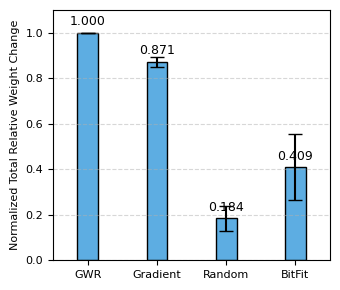

In [8]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ✅ 필요한 dictionary들
shared_key_remap = {
    "q_proj": {
        "weight": {
            "base": "q_proj.base_Linear.weight",
            "tunable": "q_proj.tunable_weight",
            "pretrained": "q_proj.weight"
        },
        "bias": {
            "base": "q_proj.base_Linear.bias",
            "pretrained": "q_proj.bias"
        }
    },
    "v_proj": {
        "weight": {
            "base": "v_proj.base_Linear.weight",
            "tunable": "v_proj.tunable_weight",
            "pretrained": "v_proj.weight"
        },
        "bias": {
            "base": "v_proj.base_Linear.bias",
            "pretrained": "v_proj.bias"
        }
    }
}

method_key_remap = {
    "BitFit": shared_key_remap,
    "Gradient": shared_key_remap,
    "Random": shared_key_remap,
    "GWR": shared_key_remap
}

method_to_folder = {
    "GWR": "gradweight_masking_0.999-1e-5",
    "Gradient": "gradient_masking_0.999-1e-5",
    "Random": "random_masking_0.999-1e-3",
    "BitFit": "bitfit-1e-5",
}

# ✅ relative change 계산 함수 (총합만 반환)
def compute_total_relative_change(w_ref, w_new):
    w_ref_np = w_ref.detach().cpu().numpy()
    w_new_np = w_new.detach().cpu().numpy()
    delta = np.abs(w_new_np - w_ref_np)
    denom = np.abs(w_ref_np) + 1e-8
    rel_change = delta / denom
    return rel_change.sum()

# ✅ seed별 실험 결과 저장
seed_results = {
    10283: None,
    28: None,
    210: None,
}

# ✅ seed 루프
for seed in seed_results.keys():
    base_dir = "parameters/WIC_125m"
    pretrained_path = "parameters/opt125m_pretrained_weights.pt"
    epoch_name = "epoch10_layer_weights.pt"
    layers = list(range(12))

    method_changes = {}
    pretrained_weights = torch.load(pretrained_path, map_location="cpu")

    for method, folder_prefix in method_to_folder.items():
        is_fft = method == "FFT"
        path_epoch = os.path.join(base_dir, f"{folder_prefix}-{seed}", epoch_name)

        if not os.path.exists(path_epoch):
            print(f"❌ Missing weights for {method} - seed {seed}")
            continue

        method_weights = torch.load(path_epoch, map_location="cpu")
        total_rel_change = 0.0

        for layer in layers:
            if is_fft:
                prefix = f"model.decoder.layers.{layer}.self_attn."
                for key in method_weights:
                    if key.startswith(prefix) and key in pretrained_weights:
                        w_new = method_weights[key]
                        w_ref = pretrained_weights[key]
                        total_rel_change += compute_total_relative_change(w_ref, w_new)
            else:
                for proj in ["q_proj", "v_proj"]:
                    remap = method_key_remap[method][proj]

                    # ✅ weight
                    try:
                        base_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['base']}"
                        tunable_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['tunable']}"
                        pretrained_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['pretrained']}"

                        base_weight = method_weights[base_key]
                        tunable_weight = method_weights[tunable_key]
                        effective_weight = base_weight + tunable_weight
                        pretrained_weight = pretrained_weights[pretrained_key]

                        total_rel_change += compute_total_relative_change(pretrained_weight, effective_weight)
                    except KeyError:
                        continue

                    # ✅ bias
                    try:
                        base_bias_key = f"model.decoder.layers.{layer}.self_attn.{remap['bias']['base']}"
                        pretrained_bias_key = f"model.decoder.layers.{layer}.self_attn.{remap['bias']['pretrained']}"

                        base_bias = method_weights[base_bias_key]
                        pretrained_bias = pretrained_weights[pretrained_bias_key]

                        total_rel_change += compute_total_relative_change(pretrained_bias, base_bias)
                    except KeyError:
                        continue

        method_changes[method] = total_rel_change

    # ✅ 정규화
    max_value = max(method_changes.values()) if method_changes else 1.0
    normalized_changes = {k: v / max_value for k, v in method_changes.items()}
    seed_results[seed] = normalized_changes

# ✅ 모든 seed 결과 정리
methods = list(seed_results[10283].keys())
all_means, all_stds = [], []

for method in methods:
    vals = [seed_results[seed][method] for seed in seed_results]
    vals = np.array(vals)
    all_means.append(vals.mean())
    all_stds.append(vals.std())

# ✅ 시각화
plt.figure(figsize=(3.5, 3))
bars = plt.bar(methods, all_means,
               yerr=all_stds, capsize=5,
               color="#5DADE2", edgecolor="black", linewidth=1, width=0.3)
plt.ylabel("Normalized Total Relative Weight Change", fontsize=8)
plt.xticks(fontsize=8, rotation=0, ha="center")
plt.yticks(fontsize=8)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.3f}",
             ha='center', va='bottom', fontsize=9)

plt.ylim(0, 1.1)
plt.xlim(-0.5, len(methods) - 0.5)
plt.tight_layout()
plt.show()


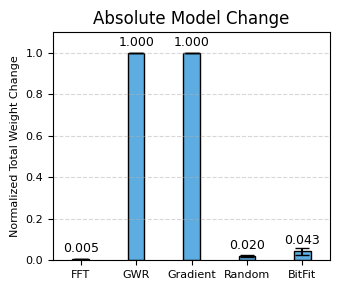

In [48]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ✅ 필요한 dictionary들
shared_key_remap = {
    "q_proj": {
        "weight": {
            "base": "q_proj.base_Linear.weight",
            "tunable": "q_proj.tunable_weight",
            "pretrained": "q_proj.weight"
        },
        "bias": {
            "base": "q_proj.base_Linear.bias",
            "pretrained": "q_proj.bias"
        }
    },
    "v_proj": {
        "weight": {
            "base": "v_proj.base_Linear.weight",
            "tunable": "v_proj.tunable_weight",
            "pretrained": "v_proj.weight"
        },
        "bias": {
            "base": "v_proj.base_Linear.bias",
            "pretrained": "v_proj.bias"
        }
    }
}

method_key_remap = {
    "BitFit": shared_key_remap,
    "Gradient": shared_key_remap,
    "Random": shared_key_remap,
    "GWR": shared_key_remap
}

method_to_folder = {
    "FFT": "fft-1e-6",
    "GWR": "gradweight_masking_0.999-1e-5",
    "Gradient": "gradient_masking_0.999-1e-5",
    "Random": "random_masking_0.999-1e-3",
    "BitFit": "bitfit-1e-5"
}

# ✅ total 변화량 계산 함수
def compute_absolute_change(w_ref, w_new):
    delta = torch.abs(w_new - w_ref)
    return delta.sum().item()

# ✅ seed별 실험 결과 저장
seed_results = {
    10283: None,
    28: None,
    210: None,
}

# ✅ seed 루프
for seed in seed_results.keys():
    base_dir = "parameters/WIC_125m"
    pretrained_path = "parameters/opt125m_pretrained_weights.pt"
    epoch_name = "epoch10_layer_weights.pt"
    layers = list(range(12))

    method_changes = {}
    pretrained_weights = torch.load(pretrained_path, map_location="cpu")

    for method, folder_prefix in method_to_folder.items():
        is_fft = method == "FFT"
        path_epoch = os.path.join(base_dir, f"{folder_prefix}-{seed}", epoch_name)

        if not os.path.exists(path_epoch):
            print(f"❌ Missing weights for {method} - seed {seed}")
            continue

        method_weights = torch.load(path_epoch, map_location="cpu")
        total_abs_change = 0.0

        for layer in layers:
            if is_fft:
                prefix = f"model.decoder.layers.{layer}.self_attn."
                for key in method_weights:
                    if key.startswith(prefix) and key in pretrained_weights:
                        w_new = method_weights[key]
                        w_ref = pretrained_weights[key]
                        total_abs_change += compute_absolute_change(w_ref, w_new)
            else:
                for proj in ["q_proj", "v_proj"]:
                    remap = method_key_remap[method][proj]

                    # ✅ weight
                    try:
                        base_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['base']}"
                        tunable_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['tunable']}"
                        pretrained_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['pretrained']}"

                        base_weight = method_weights[base_key]
                        tunable_weight = method_weights[tunable_key]
                        effective_weight = base_weight + tunable_weight
                        pretrained_weight = pretrained_weights[pretrained_key]

                        total_abs_change += compute_absolute_change(pretrained_weight, effective_weight)
                    except KeyError:
                        continue

                    # ✅ bias
                    try:
                        base_bias_key = f"model.decoder.layers.{layer}.self_attn.{remap['bias']['base']}"
                        pretrained_bias_key = f"model.decoder.layers.{layer}.self_attn.{remap['bias']['pretrained']}"

                        base_bias = method_weights[base_bias_key]
                        pretrained_bias = pretrained_weights[pretrained_bias_key]

                        total_abs_change += compute_absolute_change(pretrained_bias, base_bias)
                    except KeyError:
                        continue

        method_changes[method] = total_abs_change

    # ✅ 정규화
    max_value = max(method_changes.values()) if method_changes else 1.0
    normalized_changes = {k: v / max_value for k, v in method_changes.items()}
    seed_results[seed] = normalized_changes

# ✅ 모든 seed 결과 정리
methods = list(seed_results[10283].keys())
all_means, all_stds = [], []

for method in methods:
    vals = [seed_results[seed][method] for seed in seed_results]
    vals = np.array(vals)
    all_means.append(vals.mean())
    all_stds.append(vals.std())

# ✅ 시각화
plt.figure(figsize=(3.5, 3))
bars = plt.bar(methods, all_means,
               yerr=all_stds, capsize=5,
               color="#5DADE2", edgecolor="black", linewidth=1, width=0.3)
plt.title('Absolute Model Change')
plt.ylabel("Normalized Total Weight Change", fontsize=8)
plt.xticks(fontsize=8, rotation=0, ha="center")
plt.yticks(fontsize=8)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.3f}",
             ha='center', va='bottom', fontsize=9)

plt.ylim(0, 1.1)
plt.xlim(-0.5, len(methods) - 0.5)
plt.tight_layout()
plt.show()


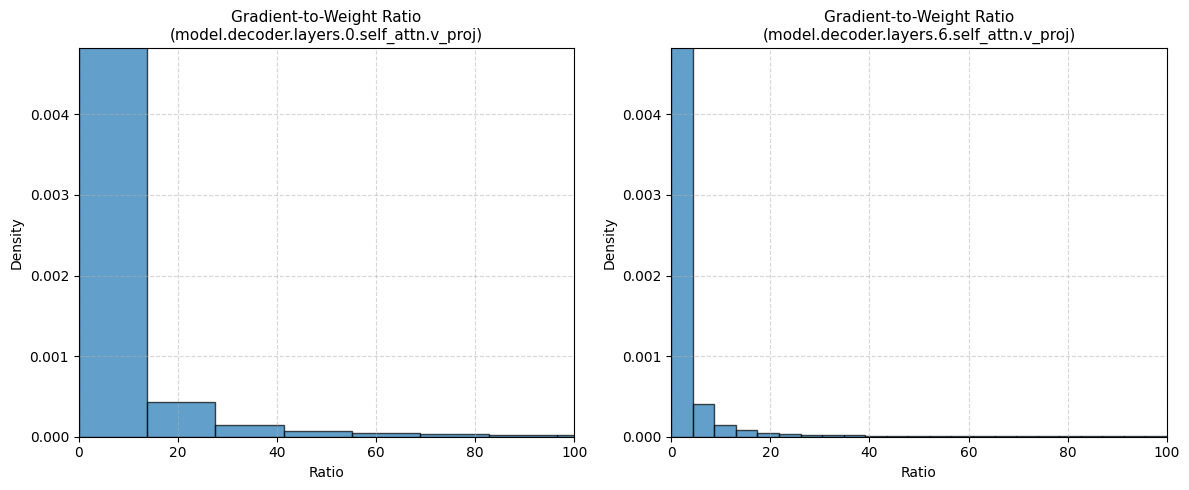

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ✅ 파일 경로
grad_path = "parameters/opt1.3b_gradients_BoolQ.pt"
weight_path = "parameters/opt1.3b_pretrained_weights.pt"

# ✅ Load
gradients = torch.load(grad_path, map_location="cpu")
weights = torch.load(weight_path, map_location="cpu")

# ✅ 관심 레이어 이름
layer_names = [
    "model.decoder.layers.0.self_attn.v_proj",
    "model.decoder.layers.6.self_attn.v_proj"
]

# ✅ 먼저 density 최대값 찾기
densities = []

for layer in layer_names:
    grad = gradients[layer + ".weight"].flatten()
    weight = weights[layer + ".weight"].flatten()
    grad_to_weight = (grad / (weight + 1e-8)).abs()

    counts, bin_edges = np.histogram(grad_to_weight.detach().numpy(), bins=2000, density=True)
    densities.append(counts.max())

max_density = max(densities)

# ✅ Plot
plt.figure(figsize=(12, 5))

for i, layer in enumerate(layer_names):
    grad = gradients[layer + ".weight"].flatten()
    weight = weights[layer + ".weight"].flatten()
    grad_to_weight = (grad / (weight + 1e-8)).abs()

    plt.subplot(1, 2, i + 1)
    plt.hist(grad_to_weight.detach().numpy(), bins=100000, density=True, alpha=0.7, edgecolor="black")
    plt.xlim(0, 100)
    plt.ylim(0, max_density * 1.05)  # ✅ 최대 density에 맞춰서 통일
    plt.title(f"Gradient-to-Weight Ratio\n({layer})", fontsize=11)
    plt.xlabel("Ratio", fontsize=10)
    plt.ylabel("Density", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

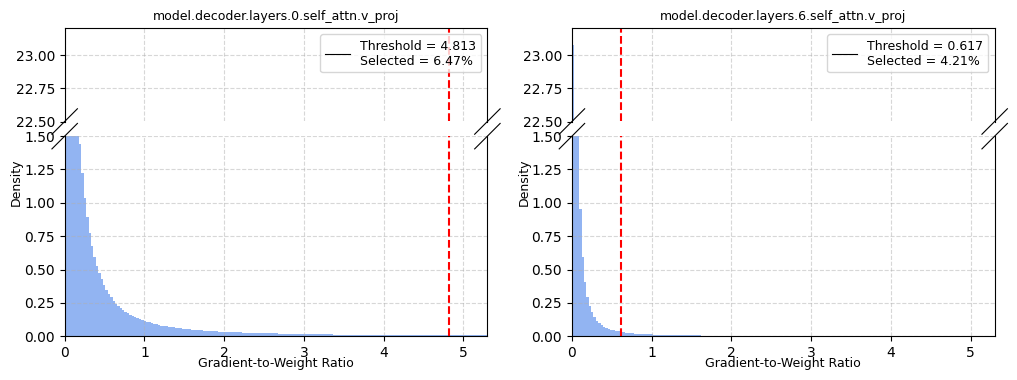

In [84]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from brokenaxes import brokenaxes  # pip install brokenaxes

# ✅ 파일 경로
grad_path = "parameters/opt1.3b_gradients_BoolQ.pt"
weight_path = "parameters/opt1.3b_pretrained_weights.pt"

# ✅ Load
gradients = torch.load(grad_path, map_location="cpu")
weights = torch.load(weight_path, map_location="cpu")

# ✅ 관심 레이어 이름과 threshold, layer ratio
layer_names = [
    "model.decoder.layers.0.self_attn.v_proj",
    "model.decoder.layers.6.self_attn.v_proj"
]
thresholds = [4.813176, 0.617246]
layer_ratios = [0.064719, 0.042113]

# ✅ 먼저 density 최대값 찾기
densities = []
grad_to_weight_list = []

for layer in layer_names:
    grad = gradients[layer + ".weight"].flatten()
    weight = weights[layer + ".weight"].flatten()
    grad_to_weight = (grad / (weight + 1e-8)).abs()
    grad_to_weight_list.append(grad_to_weight)

    counts, _ = np.histogram(grad_to_weight.detach().numpy(), bins=500, range=(0, 5.3), density=True)
    densities.append(counts.max())

max_density = max(densities)

fig = plt.figure(figsize=(12, 4))
gs = fig.add_gridspec(1, 2)

for i, grad_to_weight in enumerate(grad_to_weight_list):
    bax = brokenaxes(
        ylims=((0, 1.5), (22.5, 23.2)),
        subplot_spec=gs[i],
        despine=False,
        hspace = 0.1
    )

    grad_vals = grad_to_weight.detach().numpy()
    bax.hist(
        grad_vals,
        bins=200, range=(0, 6), density=True,
        alpha=0.7, edgecolor="none", color="cornflowerblue"
    )
    bax.axvline(thresholds[i], color='red', linestyle='--', linewidth=1.5)
    bax.set_xlim(0, 5.3)
    bax.set_xlabel("Gradient-to-Weight Ratio", fontsize=9)
    bax.set_ylabel("Density", fontsize=9)
    bax.set_title(f"{layer_names[i]}", fontsize=9)
    bax.grid(True, linestyle="--", alpha=0.5)
    bax.axs[0].legend([
        f"Threshold = {thresholds[i]:.3f}\nSelected = {layer_ratios[i]*100:.2f}%"
    ], loc="upper right", fontsize=9)



# topk-mass - BoolQ

In [96]:
import torch
import numpy as np

# ✅ 설정
grad_path = "parameters/opt1.3b_gradients_BoolQ.pt"
weight_path = "parameters/opt1.3b_pretrained_weights.pt"
topk_percent = 0.1/46/100  # 예: 0.1 = 상위 10%

# ✅ Load
gradients = torch.load(grad_path, map_location="cpu")
weights = torch.load(weight_path, map_location="cpu")

# ✅ 분석 대상: Q, V projection
projection_types = ["q_proj", "v_proj"]
num_layers = 32  # OPT-1.3B 기준 32개 layer

# ✅ 결과 저장
results = []
topk_masses = []

for l in range(num_layers):
    for proj in projection_types:
        key = f"model.decoder.layers.{l}.self_attn.{proj}.weight"
        if key not in gradients or key not in weights:
            continue
        
        grad = gradients[key].flatten()
        weight = weights[key].flatten()
        
        metric = (grad / (weight + 1e-8)).abs().detach().numpy()
        sorted_metric = np.sort(metric)[::-1]

        k = int(len(metric) * topk_percent)
        topk_mass = np.sum(sorted_metric[:k]) / (np.sum(sorted_metric) + 1e-8)

        results.append((l, proj, topk_mass))
        topk_masses.append(topk_mass)

# ✅ 정리 및 출력
print(f"\n🔍 Top-{topk_percent*100:.6f}% Importance Mass per Layer:")
for l, proj, mass in results:
    print(f"Layer {l:2d} | {proj:6s} | Top-{topk_percent*100:.6f}% mass: {mass*100:.2f}%")

# ✅ 전체 평균 출력
avg_mass = np.mean(topk_masses)
print(f"\n✅ Overall Top-{topk_percent*100:.6f}% Mass (avg): {avg_mass*100:.2f}%")


🔍 Top-0.002174% Importance Mass per Layer:
Layer  0 | q_proj | Top-0.002174% mass: 43.49%
Layer  0 | v_proj | Top-0.002174% mass: 48.25%
Layer  1 | q_proj | Top-0.002174% mass: 36.00%
Layer  1 | v_proj | Top-0.002174% mass: 74.72%
Layer  2 | q_proj | Top-0.002174% mass: 44.12%
Layer  2 | v_proj | Top-0.002174% mass: 69.95%
Layer  3 | q_proj | Top-0.002174% mass: 30.63%
Layer  3 | v_proj | Top-0.002174% mass: 92.80%
Layer  4 | q_proj | Top-0.002174% mass: 64.07%
Layer  4 | v_proj | Top-0.002174% mass: 70.34%
Layer  5 | q_proj | Top-0.002174% mass: 46.16%
Layer  5 | v_proj | Top-0.002174% mass: 93.26%
Layer  6 | q_proj | Top-0.002174% mass: 43.90%
Layer  6 | v_proj | Top-0.002174% mass: 54.47%
Layer  7 | q_proj | Top-0.002174% mass: 35.39%
Layer  7 | v_proj | Top-0.002174% mass: 66.48%
Layer  8 | q_proj | Top-0.002174% mass: 48.49%
Layer  8 | v_proj | Top-0.002174% mass: 60.76%
Layer  9 | q_proj | Top-0.002174% mass: 35.41%
Layer  9 | v_proj | Top-0.002174% mass: 57.18%
Layer 10 | q_pro

In [95]:
# topk-mass for norm only
import torch
import numpy as np

# ✅ 경로 설정
grad_path = "parameters/opt1.3b_gradients_BoolQ.pt"
weight_path = "parameters/opt1.3b_pretrained_weights.pt"

# ✅ Load gradients and weights
gradients = torch.load(grad_path, map_location="cpu")
weights = torch.load(weight_path, map_location="cpu")

# ✅ Layer별 n_tuning_params (v_proj, q_proj 순서)
n_tuning_params_list = [
    41323, 686,
    90813, 357,
    75803, 267,
    242115, 139,
    33740, 895,
    562012, 1349,
    44041, 572,
    47477, 623,
    66153, 477,
    26938, 428,
    29179, 740,
    12923, 1336,
    16420, 268,
    10453, 973,
    6481, 613,
    10222, 641,
    8762, 489,
    3844, 3139,
    7086, 1415,
    6085, 935,
    126271, 1409,
    17807, 1691,
    7786, 382,
    3291, 214
]

# ✅ 계산 및 출력
results = []
topk_masses = []

for layer in range(24):
    for j, proj in enumerate(["v_proj", "q_proj"]):
        idx = layer * 2 + j
        n_k = n_tuning_params_list[idx]
        key = f"model.decoder.layers.{layer}.self_attn.{proj}.weight"
        if key not in gradients or key not in weights:
            continue

        grad = gradients[key].flatten()
        weight = weights[key].flatten()
        metric = (grad / (weight + 1e-8)).abs().detach().numpy()
        sorted_metric = np.sort(metric)[::-1]

        k = min(n_k, len(metric))
        topk_mass = np.sum(sorted_metric[:k]) / (np.sum(sorted_metric) + 1e-8)

        results.append((layer, proj, n_k, topk_mass))
        topk_masses.append(topk_mass)

        print(f"Layer {layer:2d} | {proj:6s} | Tuning Params: {n_k:6d} | Top-k Mass: {topk_mass*100:.2f}%")

# ✅ 전체 평균 Top-k Mass
avg_topk_mass = np.mean(topk_masses)
print(f"\n✅ Overall Top-k Mass (GEM): {avg_topk_mass*100:.2f}%")

Layer  0 | v_proj | Tuning Params:  41323 | Top-k Mass: 80.90%
Layer  0 | q_proj | Tuning Params:    686 | Top-k Mass: 55.27%
Layer  1 | v_proj | Tuning Params:  90813 | Top-k Mass: 98.14%
Layer  1 | q_proj | Tuning Params:    357 | Top-k Mass: 46.61%
Layer  2 | v_proj | Tuning Params:  75803 | Top-k Mass: 98.51%
Layer  2 | q_proj | Tuning Params:    267 | Top-k Mass: 51.13%
Layer  3 | v_proj | Tuning Params: 242115 | Top-k Mass: 99.81%
Layer  3 | q_proj | Tuning Params:    139 | Top-k Mass: 33.69%
Layer  4 | v_proj | Tuning Params:  33740 | Top-k Mass: 98.05%
Layer  4 | q_proj | Tuning Params:    895 | Top-k Mass: 73.29%
Layer  5 | v_proj | Tuning Params: 562012 | Top-k Mass: 99.90%
Layer  5 | q_proj | Tuning Params:   1349 | Top-k Mass: 62.33%
Layer  6 | v_proj | Tuning Params:  44041 | Top-k Mass: 96.80%
Layer  6 | q_proj | Tuning Params:    572 | Top-k Mass: 55.63%
Layer  7 | v_proj | Tuning Params:  47477 | Top-k Mass: 97.73%
Layer  7 | q_proj | Tuning Params:    623 | Top-k Mass:

In [93]:
# topk-mass for GEM
import torch
import numpy as np

# ✅ 경로 설정
grad_path = "parameters/opt1.3b_gradients_BoolQ.pt"
weight_path = "parameters/opt1.3b_pretrained_weights.pt"

# ✅ Load gradients and weights
gradients = torch.load(grad_path, map_location="cpu")
weights = torch.load(weight_path, map_location="cpu")

# ✅ Layer별 n_tuning_params (v_proj, q_proj 순서)
n_tuning_params_list = [
    85154, 1461,
    96125, 719,
    81547, 522,
    171819, 314,
    43489, 1759,
    290389, 2285,
    55410, 1113,
    63514, 1296,
    67685, 977,
    39554, 950,
    44799, 1480,
    21855, 2684,
    24112, 606,
    17647, 2006,
    11687, 1367,
    16253, 1418,
    14900, 1113,
    7229, 5526,
    11395, 2961,
    10278, 2009,
    60896, 2966,
    22161, 3251,
    11684, 878,
    6028, 463
]

# ✅ 계산 및 출력
results = []
topk_masses = []

for layer in range(24):
    for j, proj in enumerate(["v_proj", "q_proj"]):
        idx = layer * 2 + j
        n_k = n_tuning_params_list[idx]
        key = f"model.decoder.layers.{layer}.self_attn.{proj}.weight"
        if key not in gradients or key not in weights:
            continue

        grad = gradients[key].flatten()
        weight = weights[key].flatten()
        metric = (grad / (weight + 1e-8)).abs().detach().numpy()
        sorted_metric = np.sort(metric)[::-1]

        k = min(n_k, len(metric))
        topk_mass = np.sum(sorted_metric[:k]) / (np.sum(sorted_metric) + 1e-8)

        results.append((layer, proj, n_k, topk_mass))
        topk_masses.append(topk_mass)

        print(f"Layer {layer:2d} | {proj:6s} | Tuning Params: {n_k:6d} | Top-k Mass: {topk_mass*100:.2f}%")

# ✅ 전체 평균 Top-k Mass
avg_topk_mass = np.mean(topk_masses)
print(f"\n✅ Overall Top-k Mass (GEM): {avg_topk_mass*100:.2f}%")


Layer  0 | v_proj | Tuning Params:  85154 | Top-k Mass: 84.78%
Layer  0 | q_proj | Tuning Params:   1461 | Top-k Mass: 59.52%
Layer  1 | v_proj | Tuning Params:  96125 | Top-k Mass: 98.18%
Layer  1 | q_proj | Tuning Params:    719 | Top-k Mass: 51.71%
Layer  2 | v_proj | Tuning Params:  81547 | Top-k Mass: 98.55%
Layer  2 | q_proj | Tuning Params:    522 | Top-k Mass: 55.50%
Layer  3 | v_proj | Tuning Params: 171819 | Top-k Mass: 99.78%
Layer  3 | q_proj | Tuning Params:    314 | Top-k Mass: 39.69%
Layer  4 | v_proj | Tuning Params:  43489 | Top-k Mass: 98.22%
Layer  4 | q_proj | Tuning Params:   1759 | Top-k Mass: 75.96%
Layer  5 | v_proj | Tuning Params: 290389 | Top-k Mass: 99.85%
Layer  5 | q_proj | Tuning Params:   2285 | Top-k Mass: 65.31%
Layer  6 | v_proj | Tuning Params:  55410 | Top-k Mass: 97.04%
Layer  6 | q_proj | Tuning Params:   1113 | Top-k Mass: 59.58%
Layer  7 | v_proj | Tuning Params:  63514 | Top-k Mass: 97.94%
Layer  7 | q_proj | Tuning Params:   1296 | Top-k Mass:

# topk-mass - SST2

In [103]:
import torch
import numpy as np

# ✅ 설정
grad_path = "parameters/opt1.3b_gradients_MultiRC.pt"
weight_path = "parameters/opt1.3b_pretrained_weights.pt"
topk_percent = 0.1/46/100  # 예: 0.1 = 상위 10%

# ✅ Load
gradients = torch.load(grad_path, map_location="cpu")
weights = torch.load(weight_path, map_location="cpu")

# ✅ 분석 대상: Q, V projection
projection_types = ["q_proj", "v_proj"]
num_layers = 32  # OPT-1.3B 기준 32개 layer

# ✅ 결과 저장
results = []
topk_masses = []

for l in range(num_layers):
    for proj in projection_types:
        key = f"model.decoder.layers.{l}.self_attn.{proj}.weight"
        if key not in gradients or key not in weights:
            continue
        
        grad = gradients[key].flatten()
        weight = weights[key].flatten()
        
        metric = (grad / (weight + 1e-8)).abs().detach().numpy()
        sorted_metric = np.sort(metric)[::-1]

        k = int(len(metric) * topk_percent)
        topk_mass = np.sum(sorted_metric[:k]) / (np.sum(sorted_metric) + 1e-8)

        results.append((l, proj, topk_mass))
        topk_masses.append(topk_mass)

# ✅ 정리 및 출력
print(f"\n🔍 Top-{topk_percent*100:.6f}% Importance Mass per Layer:")
for l, proj, mass in results:
    print(f"Layer {l:2d} | {proj:6s} | Top-{topk_percent*100:.6f}% mass: {mass*100:.2f}%")

# ✅ 전체 평균 출력
avg_mass = np.mean(topk_masses)
print(f"\n✅ Overall Top-{topk_percent*100:.6f}% Mass (avg): {avg_mass*100:.2f}%")


🔍 Top-0.002174% Importance Mass per Layer:
Layer  0 | q_proj | Top-0.002174% mass: 43.14%
Layer  0 | v_proj | Top-0.002174% mass: 41.56%
Layer  1 | q_proj | Top-0.002174% mass: 35.15%
Layer  1 | v_proj | Top-0.002174% mass: 65.25%
Layer  2 | q_proj | Top-0.002174% mass: 41.91%
Layer  2 | v_proj | Top-0.002174% mass: 90.67%
Layer  3 | q_proj | Top-0.002174% mass: 33.85%
Layer  3 | v_proj | Top-0.002174% mass: 89.86%
Layer  4 | q_proj | Top-0.002174% mass: 30.34%
Layer  4 | v_proj | Top-0.002174% mass: 52.22%
Layer  5 | q_proj | Top-0.002174% mass: 44.91%
Layer  5 | v_proj | Top-0.002174% mass: 84.08%
Layer  6 | q_proj | Top-0.002174% mass: 54.59%
Layer  6 | v_proj | Top-0.002174% mass: 57.39%
Layer  7 | q_proj | Top-0.002174% mass: 33.85%
Layer  7 | v_proj | Top-0.002174% mass: 63.23%
Layer  8 | q_proj | Top-0.002174% mass: 50.31%
Layer  8 | v_proj | Top-0.002174% mass: 67.15%
Layer  9 | q_proj | Top-0.002174% mass: 30.90%
Layer  9 | v_proj | Top-0.002174% mass: 62.76%
Layer 10 | q_pro

In [ ]:
# topk-mass for norm * entropy
import torch
import numpy as np

# ✅ 경로 설정
grad_path = "parameters/opt1.3b_gradients_MultiRC.pt"
weight_path = "parameters/opt1.3b_pretrained_weights.pt"

# ✅ Load gradients and weights
gradients = torch.load(grad_path, map_location="cpu")
weights = torch.load(weight_path, map_location="cpu")

# ✅ Layer별 n_tuning_params (v_proj, q_proj 순서)

# MultiRC
# n_tuning_params_list = [
#     46978, 2672,
#     32552, 239,
#     212053, 442,
#     323778, 1205,
#     40330, 1202,
#     204562, 1384,
#     43738, 2040,
#     75299, 565,
#     66842, 1154,
#     43127, 493,
#     12917, 1154,
#     28772, 1486,
#     18817, 2013,
#     14056, 3841,
#     11287, 1467,
#     11832, 1322,
#     9749, 703,
#     6650, 2821,
#     9589, 1973,
#     15245, 2561,
#     28034, 1085,
#     14095, 1875,
#     5314, 431,
#     5617, 373
# ]

# SST2
# n_tuning_params_list = [
#     163251, 1139,
#     115638, 214,
#     94813, 327,
#     265793, 164,
#     23968, 767,
#     263917, 878,
#     23394, 1013,
#     43705, 412,
#     58859, 970,
#     43020, 497,
#     29538, 850,
#     36477, 1286,
#     26312, 250,
#     17010, 3766,
#     12381, 409,
#     7866, 813,
#     4542, 738,
#     10538, 987,
#     11285, 2183,
#     9505, 660,
#     20323, 311,
#     4951, 238,
#     4622, 306,
#     4792, 60
# ]



# ✅ 계산 및 출력
results = []
topk_masses = []

for layer in range(24):
    for j, proj in enumerate(["v_proj", "q_proj"]):
        idx = layer * 2 + j
        n_k = n_tuning_params_list[idx]
        key = f"model.decoder.layers.{layer}.self_attn.{proj}.weight"
        if key not in gradients or key not in weights:
            continue

        grad = gradients[key].flatten()
        weight = weights[key].flatten()
        metric = (grad / (weight + 1e-8)).abs().detach().numpy()
        sorted_metric = np.sort(metric)[::-1]

        k = min(n_k, len(metric))
        topk_mass = np.sum(sorted_metric[:k]) / (np.sum(sorted_metric) + 1e-8)

        results.append((layer, proj, n_k, topk_mass))
        topk_masses.append(topk_mass)

        print(f"Layer {layer:2d} | {proj:6s} | Tuning Params: {n_k:6d} | Top-k Mass: {topk_mass*100:.2f}%")

# ✅ 전체 평균 Top-k Mass
avg_topk_mass = np.mean(topk_masses)
print(f"\n✅ Overall Top-k Mass (GEM): {avg_topk_mass*100:.2f}%")


Layer  0 | v_proj | Tuning Params:  46978 | Top-k Mass: 80.32%
Layer  0 | q_proj | Tuning Params:   2672 | Top-k Mass: 63.97%
Layer  1 | v_proj | Tuning Params:  32552 | Top-k Mass: 97.65%
Layer  1 | q_proj | Tuning Params:    239 | Top-k Mass: 41.88%
Layer  2 | v_proj | Tuning Params: 212053 | Top-k Mass: 99.75%
Layer  2 | q_proj | Tuning Params:    442 | Top-k Mass: 53.25%
Layer  3 | v_proj | Tuning Params: 323778 | Top-k Mass: 99.79%
Layer  3 | q_proj | Tuning Params:   1205 | Top-k Mass: 52.85%
Layer  4 | v_proj | Tuning Params:  40330 | Top-k Mass: 97.23%
Layer  4 | q_proj | Tuning Params:   1202 | Top-k Mass: 49.84%
Layer  5 | v_proj | Tuning Params: 204562 | Top-k Mass: 99.50%
Layer  5 | q_proj | Tuning Params:   1384 | Top-k Mass: 61.14%
Layer  6 | v_proj | Tuning Params:  43738 | Top-k Mass: 96.99%
Layer  6 | q_proj | Tuning Params:   2040 | Top-k Mass: 69.91%
Layer  7 | v_proj | Tuning Params:  75299 | Top-k Mass: 97.75%
Layer  7 | q_proj | Tuning Params:    565 | Top-k Mass:

In [102]:
# topk-mass for norm only
import torch
import numpy as np

# ✅ 경로 설정
grad_path = "parameters/opt1.3b_gradients_MultiRC.pt"
weight_path = "parameters/opt1.3b_pretrained_weights.pt"

# ✅ Load gradients and weights
gradients = torch.load(grad_path, map_location="cpu")
weights = torch.load(weight_path, map_location="cpu")

# ✅ Layer별 n_tuning_params (v_proj, q_proj 순서)

# SST2
n_tuning_params_list = [
    76315, 488,
    100906, 86,
    83733, 140,
    515805, 65,
    14778, 360,
    462749, 428,
    13477, 517,
    28087, 168,
    54289, 481,
    28865, 201,
    16939, 380,
    23969, 572,
    20705, 110,
    9830, 2243,
    6973, 174,
    4362, 352,
    2237, 291,
    5817, 435,
    7417, 1085,
    5695, 285,
    17129, 137,
    2869, 97,
    2563, 137,
    2295, 25
]

# MultiRC
# n_tuning_params_list = [
#     19906, 1285,
#     21552, 96,
#     446948, 196,
#     488086, 488,
#     22618, 492,
#     233088, 646,
#     27776, 1059,
#     47768, 222,
#     57757, 531,
#     25903, 199,
#     6177, 481,
#     15417, 591,
#     11359, 831,
#     6677, 1752,
#     5363, 575,
#     6035, 553,
#     4648, 287,
#     2958, 1225,
#     4958, 764,
#     8784, 1089,
#     24117, 416,
#     8814, 773,
#     2805, 163,
#     2677, 154
# ]


# ✅ 계산 및 출력
results = []
topk_masses = []

for layer in range(24):
    for j, proj in enumerate(["v_proj", "q_proj"]):
        idx = layer * 2 + j
        n_k = n_tuning_params_list[idx]
        key = f"model.decoder.layers.{layer}.self_attn.{proj}.weight"
        if key not in gradients or key not in weights:
            continue

        grad = gradients[key].flatten()
        weight = weights[key].flatten()
        metric = (grad / (weight + 1e-8)).abs().detach().numpy()
        sorted_metric = np.sort(metric)[::-1]

        k = min(n_k, len(metric))
        topk_mass = np.sum(sorted_metric[:k]) / (np.sum(sorted_metric) + 1e-8)

        results.append((layer, proj, n_k, topk_mass))
        topk_masses.append(topk_mass)

        print(f"Layer {layer:2d} | {proj:6s} | Tuning Params: {n_k:6d} | Top-k Mass: {topk_mass*100:.2f}%")

# ✅ 전체 평균 Top-k Mass
avg_topk_mass = np.mean(topk_masses)
print(f"\n✅ Overall Top-k Mass (GEM): {avg_topk_mass*100:.2f}%")


Layer  0 | v_proj | Tuning Params:  76315 | Top-k Mass: 83.26%
Layer  0 | q_proj | Tuning Params:    488 | Top-k Mass: 53.65%
Layer  1 | v_proj | Tuning Params: 100906 | Top-k Mass: 98.46%


KeyboardInterrupt: 

# Relative Update vs. Parameter tuning percentage

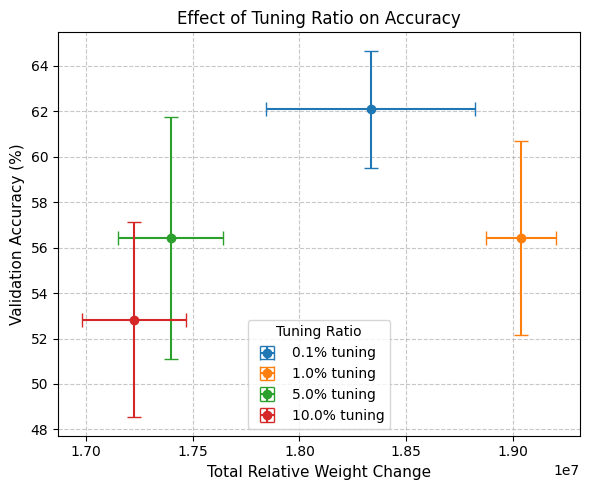

In [11]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ✅ 구조 설정
shared_key_remap = {
    "q_proj": {
        "weight": {
            "base": "q_proj.base_Linear.weight",
            "tunable": "q_proj.tunable_weight",
            "pretrained": "q_proj.weight"
        },
        "bias": {
            "base": "q_proj.base_Linear.bias",
            "pretrained": "q_proj.bias"
        }
    },
    "v_proj": {
        "weight": {
            "base": "v_proj.base_Linear.weight",
            "tunable": "v_proj.tunable_weight",
            "pretrained": "v_proj.weight"
        },
        "bias": {
            "base": "v_proj.base_Linear.bias",
            "pretrained": "v_proj.bias"
        }
    }
}

method_key_remap = {
    "Gradient": shared_key_remap
}

# ✅ 하이퍼파라미터
mask_ratios = [0.999, 0.99, 0.95, 0.9]
method_name = "Gradient"
lr_str = "1e-5"
seeds = [28, 210, 10283]
pretrained_path = "parameters/opt125m_pretrained_weights.pt"
base_dir = "parameters/RTE_125m"
epoch_name = "epoch10_layer_weights.pt"

# ✅ Accuracy 수동 입력 (각 비율에 대해 seed별)
accuracy_dict = {
    0.999: [63.54, 58.48, 64.26],
    0.99: [51.26, 56.32, 61.73],
    0.95: [53.79, 51.62, 63.85],
    0.9: [46.93, 54.51, 57.04],
}

# ✅ 상대 변화량 계산 함수
def compute_total_relative_change(w_ref, w_new):
    w_ref_np = w_ref.detach().cpu().numpy()
    w_new_np = w_new.detach().cpu().numpy()
    delta = np.abs(w_new_np - w_ref_np)
    denom = np.abs(w_ref_np) + 1e-8
    rel_change = delta / denom
    return rel_change.sum()

# ✅ 전체 변화 저장
results = {ratio: [] for ratio in mask_ratios}
pretrained_weights = torch.load(pretrained_path, map_location="cpu")

for seed in seeds:
    for mask_ratio in mask_ratios:
        folder_name = f"gradweight_masking_{mask_ratio}-{lr_str}-{seed}"
        path_epoch = os.path.join(base_dir, folder_name, epoch_name)
        if not os.path.exists(path_epoch):
            print(f"❌ Missing weights for {folder_name}")
            continue
        method_weights = torch.load(path_epoch, map_location="cpu")
        total_rel_change = 0.0
        for layer in range(12):
            for proj in ["q_proj", "v_proj"]:
                remap = method_key_remap[method_name][proj]
                try:
                    base_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['base']}"
                    tunable_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['tunable']}"
                    pretrained_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['pretrained']}"
                    base_weight = method_weights[base_key]
                    tunable_weight = method_weights[tunable_key]
                    effective_weight = base_weight + tunable_weight
                    pretrained_weight = pretrained_weights[pretrained_key]
                    total_rel_change += compute_total_relative_change(pretrained_weight, effective_weight)
                except KeyError:
                    continue
                try:
                    base_bias_key = f"model.decoder.layers.{layer}.self_attn.{remap['bias']['base']}"
                    pretrained_bias_key = f"model.decoder.layers.{layer}.self_attn.{remap['bias']['pretrained']}"
                    base_bias = method_weights[base_bias_key]
                    pretrained_bias = pretrained_weights[pretrained_bias_key]
                    total_rel_change += compute_total_relative_change(pretrained_bias, base_bias)
                except KeyError:
                    continue
        results[mask_ratio].append(total_rel_change)

# ✅ 시각화용 집계
plt.figure(figsize=(6, 5))
for ratio in mask_ratios:
    changes = results[ratio]
    accs = accuracy_dict[ratio]
    if len(changes) == len(accs):
        mean_change = np.mean(changes)
        std_change = np.std(changes)
        mean_acc = np.mean(accs)
        std_acc = np.std(accs)
        plt.errorbar(mean_change, mean_acc, xerr=std_change, yerr=std_acc,
                     fmt='o', capsize=5, label=f"{(1 - ratio)*100:.1f}% tuning")

# ✅ plot 설정
plt.xlabel("Total Relative Weight Change", fontsize=11)
plt.ylabel("Validation Accuracy (%)", fontsize=11)
plt.title("Effect of Tuning Ratio on Accuracy", fontsize=12)
plt.legend(title="Tuning Ratio")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


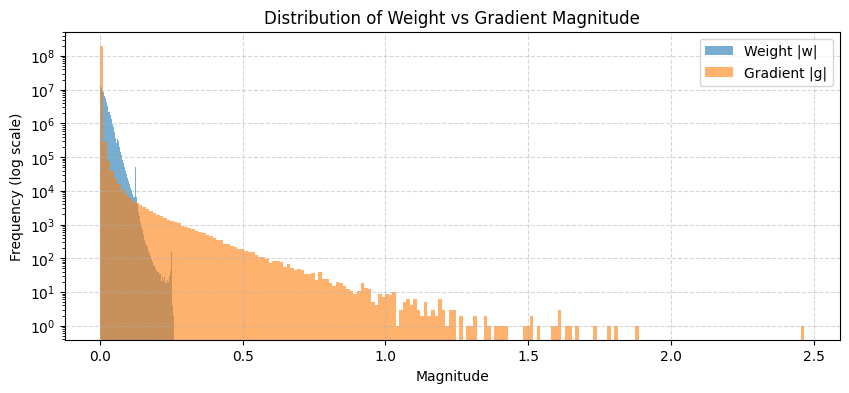

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

weights = torch.load("parameters/opt1.3b_pretrained_weights.pt", map_location='cpu')
grads = torch.load("parameters/opt1.3b_gradients_SST2.pt", map_location='cpu')

weight_vals = []
grad_vals = []

for name in weights:
    if name.endswith(".weight") and name in grads:
        weight_vals.extend(weights[name].abs().flatten().tolist())
        grad_vals.extend(grads[name].abs().flatten().tolist())

# Log histogram
plt.figure(figsize=(10, 4))
plt.hist(weight_vals, bins=200, alpha=0.6, label="Weight |w|", log=True)
plt.hist(grad_vals, bins=200, alpha=0.6, label="Gradient |g|", log=True)
plt.xlabel("Magnitude")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Weight vs Gradient Magnitude")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


[GWR | seed 10283] Loss Reduction = -0.250772
[Gradient | seed 10283] Loss Reduction = -0.188589
[Random | seed 10283] Loss Reduction = -0.044223
[BitFit | seed 10283] Loss Reduction = -0.005616
[GWR | seed 28] Loss Reduction = -0.076464
[Gradient | seed 28] Loss Reduction = -0.064469
[Random | seed 28] Loss Reduction = 0.028425
[BitFit | seed 28] Loss Reduction = -0.029813
[GWR | seed 210] Loss Reduction = -0.020852
[Gradient | seed 210] Loss Reduction = -0.002999
[Random | seed 210] Loss Reduction = 0.065404
[BitFit | seed 210] Loss Reduction = -0.019246


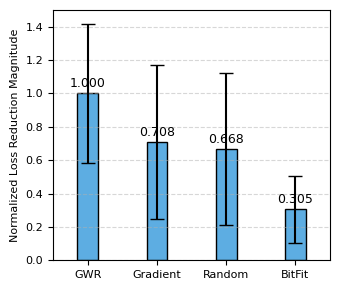

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ✅ 필요한 dictionary들
shared_key_remap = {
    "q_proj": {
        "weight": {
            "base": "q_proj.base_Linear.weight",
            "tunable": "q_proj.tunable_weight",
            "pretrained": "q_proj.weight"
        },
        "bias": {
            "base": "q_proj.base_Linear.bias",
            "pretrained": "q_proj.bias"
        }
    },
    "v_proj": {
        "weight": {
            "base": "v_proj.base_Linear.weight",
            "tunable": "v_proj.tunable_weight",
            "pretrained": "v_proj.weight"
        },
        "bias": {
            "base": "v_proj.base_Linear.bias",
            "pretrained": "v_proj.bias"
        }
    }
}

method_key_remap = {
    "BitFit": shared_key_remap,
    "Gradient": shared_key_remap,
    "Random": shared_key_remap,
    "GWR": shared_key_remap,
}

method_to_folder = {
    "GWR": "gradweight_masking_0.999-1e-5",
    "Gradient": "gradient_masking_0.999-1e-5",
    "Random": "random_masking_0.999-1e-3",
    "BitFit": "bitfit-1e-5"
}

# ✅ 공통 설정
base_dir = "parameters/RTE_125m"
pretrained_path = "parameters/opt125m_pretrained_weights.pt"
grad_path = "parameters/opt125m_gradients_RTE.pt"
epoch_name = "epoch10_layer_weights.pt"
layers = list(range(12))
seeds = [10283, 28, 210]

# ✅ Load pretrained weights and gradients
pretrained_weights = torch.load(pretrained_path, map_location="cpu")
gradients = torch.load(grad_path, map_location="cpu")

# ✅ 계산 함수: -grad · Δweight
def compute_loss_reduction(grad, delta):
    return -(grad * delta).sum().item()

# ✅ seed별 실험 결과 저장
seed_results = {seed: {} for seed in seeds}

for seed in seeds:
    for method, folder_prefix in method_to_folder.items():
        path_epoch = os.path.join(base_dir, f"{folder_prefix}-{seed}", epoch_name)
        if not os.path.exists(path_epoch):
            print(f"❌ Missing weights for {method} - seed {seed}")
            continue

        method_weights = torch.load(path_epoch, map_location="cpu")
        total_loss_reduction = 0.0

        for layer in layers:
            for proj in ["q_proj", "v_proj"]:
                remap = method_key_remap[method][proj]

                # ✅ weight
                try:
                    base_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['base']}"
                    tunable_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['tunable']}"
                    pretrained_key = f"model.decoder.layers.{layer}.self_attn.{remap['weight']['pretrained']}"
                    grad_key = grad_key = pretrained_key

                    base_weight = method_weights[base_key]
                    tunable_weight = method_weights[tunable_key]
                    effective_weight = base_weight + tunable_weight
                    pretrained_weight = pretrained_weights[pretrained_key]
                    gradient = gradients[grad_key]

                    delta = effective_weight - pretrained_weight
                    total_loss_reduction += compute_loss_reduction(gradient, delta)
                except KeyError:
                    continue

                # ✅ bias
                try:
                    base_bias_key = f"model.decoder.layers.{layer}.self_attn.{remap['bias']['base']}"
                    pretrained_bias_key = f"model.decoder.layers.{layer}.self_attn.{remap['bias']['pretrained']}"
                    grad_bias_key = pretrained_bias_key

                    base_bias = method_weights[base_bias_key]
                    pretrained_bias = pretrained_weights[pretrained_bias_key]
                    gradient_bias = gradients[grad_bias_key]

                    delta_bias = base_bias - pretrained_bias
                    total_loss_reduction += compute_loss_reduction(gradient_bias, delta_bias)
                except KeyError:
                    continue
                
        print(f"[{method} | seed {seed}] Loss Reduction = {total_loss_reduction:.6f}")
        seed_results[seed][method] = total_loss_reduction

# ✅ 정규화 및 정리
methods = list(method_to_folder.keys())
all_means, all_stds = [], []

# 정규화 (seed마다 max 기준)
normalized_results = {method: [] for method in methods}
for seed in seeds:
    max_val = max(abs(v) for v in seed_results[seed].values()) if seed_results[seed] else 1.0
    if max_val == 0:
        max_val = 1.0
    for method in methods:
        val = abs(seed_results[seed].get(method, 0.0))  # 👈 abs here
        normalized_results[method].append(val / max_val)
        
# ✅ 평균값 계산
method_to_mean = {}
method_to_std = {}

for method in methods:
    vals = np.array(normalized_results[method])
    method_to_mean[method] = vals.mean()
    method_to_std[method] = vals.std()

# ✅ 가장 큰 평균값으로 정규화
max_mean = max(method_to_mean.values())

all_means = [method_to_mean[m] / max_mean for m in methods]
all_stds = [method_to_std[m] / max_mean for m in methods]

# ✅ 시각화
plt.figure(figsize=(3.5, 3))
bars = plt.bar(methods, all_means,
               yerr=all_stds, capsize=5,
               color="#5DADE2", edgecolor="black", linewidth=1, width=0.3)
plt.ylabel("Normalized Loss Reduction Magnitude", fontsize=8)
plt.xticks(fontsize=8, rotation=0, ha="center")
plt.yticks(fontsize=8)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.3f}",
             ha='center', va='bottom', fontsize=9)

plt.ylim(0, 1.5)
plt.xlim(-0.5, len(methods) - 0.5)
plt.tight_layout()
plt.show()